# Packages

In [198]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
from plotly.graph_objs import Figure
from pathlib import Path
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from datetime import datetime, timedelta, date
import math
import re
import requests
import time

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

import scipy.stats as stats
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler, LabelEncoder, OrdinalEncoder
import gc
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: "%.4f" % x)
pd.options.plotting.backend = "plotly"

plt.style.use('ggplot')
sns.set_style('darkgrid')

# Helper Functions

In [199]:
# helper functions
def get_info(df):
    missing_values_train = pd.DataFrame({'Feature': df.columns,
                              'No. of Missing Values': df.isnull().sum().values,
                              '% of Missing Values': ((df.isnull().sum().values)/len(df)*100)})

    unique_values = pd.DataFrame({'Feature': df.columns,
                                'No. of Unique Values': df.nunique().values})

    feature_types = pd.DataFrame({'Feature': df.columns,
                                'DataType': df.dtypes})

    merged_df = pd.merge(missing_values_train, unique_values, on='Feature', how='left')
    merged_df = pd.merge(merged_df, feature_types, on='Feature', how='left')

    return merged_df

def reduce_memory_usage(df: pd.DataFrame, verbose=False) -> pd.DataFrame:
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage before: {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        elif col_type == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage after: {end_mem:.2f} MB")
        print(f"Reduced by {(start_mem - end_mem) / start_mem * 100:.1f}%")
    
    return df

# 4 States UOF Data

In [200]:
incidents_path = "./data/incidents.csv"
incidents_df = pd.read_csv(incidents_path)
incidents_df = reduce_memory_usage(incidents_df, verbose=True)

/var/folders/8r/qgk4_l1j20gfq28wvs_pxh2r0000gn/T/ipykernel_88096/2607719303.py:2: DtypeWarning: Columns (0: agency_name, 1: ori, 2: subject_age, 3: indication_of_injury, 4: incident_id, 5: NJ_County, 6: NJ_Agency Name, 7: NJ_Incident ID, 8: NJ_Report Number, 9: NJ_Incident Case Number, 10: NJ_Incident Date, 11: NJ_Incident Type, 12: NJ_Subject Actions, 13: NJ_Subject Resistance, 14: NJ_Subject Medical Treatment, 15: NJ_Subject Injury Type, 16: NJ_Subject Arrested, 17: NJ_Reason Subject Not Arrested, 18: NJ_Subject Type, 19: NJ_Subject Age, 20: NJ_Subject Race/Ethnicity, 21: NJ_Subject Gender, 22: NJ_Force Type, 23: Ohio_AgencyName, 24: Ohio_IncidentNumber, 25: Ohio_IncidentDate, 26: Ohio_InitialContactCircumstances, 27: Ohio_LocationType, 28: Ohio_SubjectResistanceTypes, 29: Ohio_SubjectArmed/BelievedToBeArmed, 30: Ohio_SubjectRaceEthnicity, 31: Ohio_SubjectGender, 32: Ohio_SubjectInjuries, 33: Ohio_SubjectImpairments, 34: Ohio_OfficerType, 35: Ohio_OfficerResponse/ForceTypes, 36: Ohio

Memory usage before: 1203.00 MB
Memory usage after: 1165.63 MB
Reduced by 3.1%


In [201]:
incidents_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE
0,11/6/2023,Berkeley Twp PD,NaN,NJ,Ocean,Hispanic,28,Male,Used take down on,NaN,"['OCEAN-BERKELEY TWP PD-23-003647', 'UOF23-11-...",866515.0000,Ocean,Berkeley Twp PD,OCEAN-BERKELEY TWP PD-23-003647,UOF23-11-52,23-003647,11/6/2023,Assault,Attempt to escape from Custody,Passive Resistor,NaN,NaN,TRUE,NaN,Person,28,Hispanic,Male,Used take down on

In [202]:
incidents_df["subject_race"].str.lower().value_counts()

subject_race
white                                                      63471
black                                                      60403
hispanic                                                   56110
black or african american                                  44978
other                                                       4497
asian                                                       3999
unknown                                                     1907
not provided                                                 916
multiracial                                                  743
middle eastern                                               579
two or more races                                            468
pacific islander                                             176
american indian/alaskan native                               173
native american                                              136
amer indian                                                  104
unknown/not 

In [203]:
incidents_df["subject_gender"].str.lower().value_counts()

subject_gender
male                    191759
female                   42861
unk                       2268
not provided               661
nonbinary                  571
unknown                    215
trans male                 137
non-binary/x               106
trans female                96
unknown/not reported        31
Name: count, dtype: int64

In [204]:
incidents_df[incidents_df["subject_gender"].str.contains("|", regex=False)]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE


## Time

In [205]:
incidents_df["date"]

0          11/6/2023
1          5/13/2021
2          1/27/2021
3           1/8/2022
4          5/11/2025
             ...    
238971    2024-08-21
238972    2024-12-27
238973    2024-07-15
238974    2024-10-01
238975    2024-10-01
Name: date, Length: 238976, dtype: str

In [206]:
incidents_df["date"] = pd.to_datetime(incidents_df["date"], errors="coerce", format="mixed")

In [207]:
incidents_df["date"]

0        2023-11-06
1        2021-05-13
2        2021-01-27
3        2022-01-08
4        2025-05-11
            ...    
238971   2024-08-21
238972   2024-12-27
238973   2024-07-15
238974   2024-10-01
238975   2024-10-01
Name: date, Length: 238976, dtype: datetime64[us]

In [208]:
incidents_df["date"].info()

<class 'pandas.Series'>
RangeIndex: 238976 entries, 0 to 238975
Series name: date
Non-Null Count   Dtype         
--------------   -----         
238976 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 1.8 MB


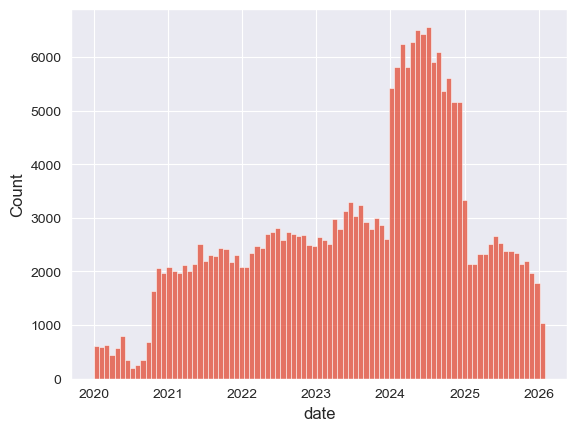

In [209]:
sns.histplot(data=incidents_df, x="date")
plt.show()

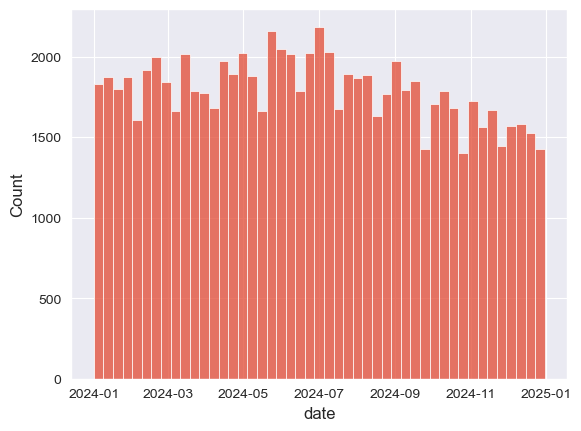

In [210]:
incidents_df = (
    incidents_df
        [lambda x: x.date.between(datetime(2024,1,1), datetime(2024,12,31), inclusive="both")]
        .sort_values(by="date")
)
sns.histplot(data=incidents_df, x="date")
plt.show()

In [211]:
incidents_df.shape

(84152, 176)

In [212]:
incidents_df["state"].value_counts()

state
CA    36375
NY    24547
NJ    19972
OH     3258
Name: count, dtype: int64

## Standardizing Race and Gender

In [213]:
incidents_df["subject_race"].value_counts()

subject_race
Hispanic                                                   22105
White                                                      21446
Black                                                      13578
Black or African American                                  10192
BLACK                                                       6665
HISPANIC                                                    3774
Asian                                                       1270
OTHER                                                        989
WHITE                                                        868
Multiracial                                                  743
Unknown                                                      627
Middle Eastern                                               579
ASIAN                                                        359
Pacific Islander                                             176
Native American                                              136
Other       

In [214]:
incidents_df["subject_gender"].value_counts()

subject_gender
Male                    56663
Female                  13657
MALE                    10392
FEMALE                   1730
Nonbinary                 571
UNK                       553
Trans Male                137
Not Provided              118
Trans Female               96
Unknown                    81
Unknown/Not Reported       31
Non-Binary/X               18
Name: count, dtype: int64

In [215]:
def standardize_race_series(s):
    s = s.str.lower()

    s = s.replace({
            r".*hispanic.*": "hispanic",
            r".*black.*": "black",
            r".*white.*": "white",
            r".*asian.*": "asian",
            r".*(native american|american indian|amer indian).*": "native american",
            r".*(native hawaiian|pacific islander).*": "pacific islander",
        }, regex=True)
    s[~s.isin(["hispanic", "black", "white", "asian", "native american", "pacific islander"])] = "unknown"
    return s

def standardize_gender_series(s):
    s = s.str.lower().str.strip()
    s = s.replace({
        r"^male$": "male",
        r"^female$": "female",
        r".*(nonbinary|trans|non-binary).*": "nonbinary",
    }, regex=True)

    s[~s.isin(["male", "female", "nonbinary"])] = "unknown"
    return s


In [216]:
incidents_df["subject_race"] = standardize_race_series(incidents_df["subject_race"])
incidents_df["subject_gender"] = standardize_gender_series(incidents_df["subject_gender"])

In [217]:
incidents_df["subject_race"].value_counts()

subject_race
black               30435
hispanic            25977
white               22316
unknown              3375
asian                1629
native american       233
pacific islander      187
Name: count, dtype: int64

In [218]:
incidents_df["subject_gender"].value_counts()

subject_gender
male         67055
female       15387
unknown        888
nonbinary      822
Name: count, dtype: int64

# NIBRS Data

In [219]:
states_of_interest = incidents_df["state"].unique()
states_of_interest

<StringArray>
['CA', 'NY', 'NJ', 'OH']
Length: 4, dtype: str

In [220]:
nibrs_path = "./data/nibrs.csv"

nibrs_df = pd.read_csv(nibrs_path)
nibrs_df = reduce_memory_usage(nibrs_df, verbose=True)

/var/folders/8r/qgk4_l1j20gfq28wvs_pxh2r0000gn/T/ipykernel_88096/1228159107.py:3: DtypeWarning: Columns (0: arrest_transaction_number, 1: multiple_arrestee_segment_indicator, 2: automatic_weapon_indicator1, 3: automatic_weapon_indicator2, 4: disposition_arrestee_under_18) have mixed types. Specify dtype option on import or set low_memory=False.
  nibrs_df = pd.read_csv(nibrs_path)


Memory usage before: 4218.64 MB
Memory usage after: 3968.49 MB
Reduced by 5.9%


In [221]:
nibrs_df = (
    nibrs_df.assign(
        state_abbr = lambda x: x.ori.str[:2]
    )
)
print(f"Shape before state filter NIBRS: {nibrs_df.shape}")
nibrs_df = nibrs_df[lambda x: x.state_abbr.isin(states_of_interest)]
print(f"Shape after state filter NIBRS: {nibrs_df.shape}")

Shape before state filter NIBRS: (5245967, 25)
Shape after state filter NIBRS: (1022295, 25)


In [222]:
nibrs_df["state_abbr"].value_counts()

state_abbr
CA    500768
NY    288637
OH    145784
NJ     87106
Name: count, dtype: int64

In [223]:
state_code_dict = {
    1: "Alabama",
    2: "Arizona",
    3: "Arkansas",
    4: "California",
    5: "Colorado",
    6: "Connecticut",
    7: "Delaware",
    8: "District of Columbia",
    9: "Florida",
    10: "Georgia",
    11: "Idaho",
    12: "Illinois",
    13: "Indiana",
    14: "Iowa",
    15: "Kansas",
    16: "Kentucky",
    17: "Louisiana",
    18: "Maine",
    19: "Maryland",
    20: "Massachusetts",
    21: "Michigan",
    22: "Minnesota",
    23: "Mississippi",
    24: "Missouri",
    25: "Montana",
    26: "Nebraska",
    27: "Nevada",
    28: "New Hampshire",
    29: "New Jersey",
    30: "New Mexico",
    31: "New York",
    32: "North Carolina",
    33: "North Dakota",
    34: "Ohio",
    35: "Oklahoma",
    36: "Oregon",
    37: "Pennsylvania",
    38: "Rhode Island",
    39: "South Carolina",
    40: "South Dakota",
    41: "Tennessee",
    42: "Texas",
    43: "Utah",
    44: "Vermont",
    45: "Virginia",
    46: "Washington",
    47: "West Virginia",
    48: "Wisconsin",
    49: "Wyoming",
    50: "Alaska",
    51: "Hawaii",
    52: "Canal Zone",
    53: "Puerto Rico",
    54: "American Samoa",
    55: "Guam",
    62: "Virgin Islands"
}
nibrs_df = nibrs_df.assign(state_name = lambda x: x.state_code.map(state_code_dict))

In [224]:
nibrs_df["ethnicity_of_arrestee"] = nibrs_df["ethnicity_of_arrestee"].fillna("U")
nibrs_df = nibrs_df.assign(
    race_ethnicity_arrestee = lambda x: 
            np.where(
                x.ethnicity_of_arrestee == 'H',
                x.ethnicity_of_arrestee,
                x.race_of_arrestee
            )
)

nibrs_df["incident_date"] = pd.to_datetime(nibrs_df["incident_date"], format="%Y-%m-%d")
nibrs_df["arrest_date"] = pd.to_datetime(nibrs_df["arrest_date"], format="%Y-%m-%d")
nibrs_df["incident_date"] = nibrs_df["incident_date"].fillna(nibrs_df["arrest_date"])

In [225]:
nibrs_df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,state_abbr,state_name,race_ethnicity_arrestee
169592,6,4,CA0010000,2K-HP2728D1A,2024-04-16,1,24-005000-1,2024-04-16,O,N,35A,1,NaN,NaN,NaN,39,M,B,N,N,NaN,2024_199084,0,NaN,CA,California,B
169593,6,4,CA0010000,2K-HP2729D1A,2024-04-16,1,24-005001-1,2024-04-16,O,N,13A,1,NaN,NaN,NaN,28,M,W,H,R,NaN,2024_199085,0,NaN,CA,California,H
169594,6,4,CA0010000,2K-HP272JD1A,2024-04-16,1,24-005005-2,2024-04-16,O,N,23C,1,NaN,NaN,NaN,20,M,B,H,U,NaN,2024_199086,0,NaN,CA,California,H
169595,6,4,CA0010000,2K-HP272JD1A,2024-04-16,2,24-005005-1,2024-04-16,O,N,23C,1,NaN,NaN,NaN,29,M,B,U,U,NaN,2024_199087,0,NaN,CA,California,B
169596,6,4,CA0010000,2K-HP272SD1A,2024-04-16,1,24-005006-1,2024-04-16,O,N,13B,1,NaN,NaN,NaN,35,F,W,H,R,NaN,2024_199088,0,NaN,CA,California,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4493422,7,34,OHOHP0000,ZI96 KOBLSX6,2024-03-18,1,NaN,2024-03-18,O,NaN,90F,1,NaN,NaN,NaN,42,M,W,H,R,NaN,2024_1979635,1,NaN,OH,Ohio,H
4493423,7,34,OHOHP0000,ZI9J KHZLSX6,2024-10-26,1,NaN,2024-10-26,T,NaN,90Z,1,NaN,NaN,NaN,19,M,W,N,N,NaN,2024_1979636,1,NaN,OH,Ohio,W
4493424,7,34,OHOHP0000,ZI9J KOBLS2A,2024-11-17,1,NaN,2024-11-17,T,NaN,90C,1,NaN,NaN,NaN,57,M,W,N,N,NaN,2024_1979637,1,NaN,OH,Ohio,W
4493425,7,34,OHOHP0000,ZI9T KORLOX,2024-07-09,1,NaN,2024-07-09,T,NaN,90Z,1,NaN,NaN,NaN,64,M,B,N,R,NaN,2024_1979638,1,NaN,OH,Ohio,B


In [226]:
nibrs_df["city_submission"].value_counts()

Series([], Name: count, dtype: int64)

In [227]:
nibrs_df = nibrs_df.drop(columns=[
    "segment_level",
    "db_id",
    "city_submission",
    "arrest_date",
    "race_of_arrestee",
    "ethnicity_of_arrestee"
])

In [228]:
nibrs_df

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,race_ethnicity_arrestee
169592,4,CA0010000,2K-HP2728D1A,2024-04-16,1,24-005000-1,O,N,35A,1,NaN,NaN,NaN,39,M,N,NaN,0,CA,California,B
169593,4,CA0010000,2K-HP2729D1A,2024-04-16,1,24-005001-1,O,N,13A,1,NaN,NaN,NaN,28,M,R,NaN,0,CA,California,H
169594,4,CA0010000,2K-HP272JD1A,2024-04-16,1,24-005005-2,O,N,23C,1,NaN,NaN,NaN,20,M,U,NaN,0,CA,California,H
169595,4,CA0010000,2K-HP272JD1A,2024-04-16,2,24-005005-1,O,N,23C,1,NaN,NaN,NaN,29,M,U,NaN,0,CA,California,B
169596,4,CA0010000,2K-HP272SD1A,2024-04-16,1,24-005006-1,O,N,13B,1,NaN,NaN,NaN,35,F,R,NaN,0,CA,California,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4493422,34,OHOHP0000,ZI96 KOBLSX6,2024-03-18,1,NaN,O,NaN,90F,1,NaN,NaN,NaN,42,M,R,NaN,1,OH,Ohio,H
4493423,34,OHOHP0000,ZI9J KHZLSX6,2024-10-26,1,NaN,T,NaN,90Z,1,NaN,NaN,NaN,19,M,N,NaN,1,OH,Ohio,W
4493424,34,OHOHP0000,ZI9J KOBLS2A,2024-11-17,1,NaN,T,NaN,90C,1,NaN,NaN,NaN,57,M,N,NaN,1,OH,Ohio,W
4493425,34,OHOHP0000,ZI9T KORLOX,2024-07-09,1,NaN,T,NaN,90Z,1,NaN,NaN,NaN,64,M,R,NaN,1,OH,Ohio,B


In [229]:
nibrs_df["race_ethnicity_arrestee"].value_counts()

race_ethnicity_arrestee
W    363077
H    317136
B    284784
A     33084
U     17025
I      4834
P      2355
Name: count, dtype: int64

In [230]:
nibrs_df["sex_of_arrestee"].value_counts()

sex_of_arrestee
M    781678
F    240617
Name: count, dtype: int64

In [231]:
def nibrs_standardize_race_series(s):
    mapping = {
        'W': 'white',
        'H': 'hispanic',
        'B': 'black',
        'A': 'asian',
        'P': 'pacific islander',
        'I': 'native american',
        'U': 'unknown'
    }
    return s.map(mapping).fillna(s)

def nibrs_standardize_gender_series(s):
    mapping = {
        'M' : 'male',
        'F' : "female"
    }
    return s.map(mapping).fillna(s)

In [232]:
nibrs_df["race_ethnicity_arrestee"] = nibrs_standardize_race_series(nibrs_df["race_ethnicity_arrestee"])
nibrs_df["sex_of_arrestee"] = nibrs_standardize_gender_series(nibrs_df["sex_of_arrestee"])
nibrs_df.rename(columns = {
    "race_ethnicity_arrestee": "subject_race",
    "sex_of_arrestee": "subject_gender",
    "age_of_arrestee": "subject_age"},
    inplace=True
)

In [233]:
nibrs_df

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
169592,4,CA0010000,2K-HP2728D1A,2024-04-16,1,24-005000-1,O,N,35A,1,NaN,NaN,NaN,39,male,N,NaN,0,CA,California,black
169593,4,CA0010000,2K-HP2729D1A,2024-04-16,1,24-005001-1,O,N,13A,1,NaN,NaN,NaN,28,male,R,NaN,0,CA,California,hispanic
169594,4,CA0010000,2K-HP272JD1A,2024-04-16,1,24-005005-2,O,N,23C,1,NaN,NaN,NaN,20,male,U,NaN,0,CA,California,hispanic
169595,4,CA0010000,2K-HP272JD1A,2024-04-16,2,24-005005-1,O,N,23C,1,NaN,NaN,NaN,29,male,U,NaN,0,CA,California,black
169596,4,CA0010000,2K-HP272SD1A,2024-04-16,1,24-005006-1,O,N,13B,1,NaN,NaN,NaN,35,female,R,NaN,0,CA,California,hispanic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4493422,34,OHOHP0000,ZI96 KOBLSX6,2024-03-18,1,NaN,O,NaN,90F,1,NaN,NaN,NaN,42,male,R,NaN,1,OH,Ohio,hispanic
4493423,34,OHOHP0000,ZI9J KHZLSX6,2024-10-26,1,NaN,T,NaN,90Z,1,NaN,NaN,NaN,19,male,N,NaN,1,OH,Ohio,white
4493424,34,OHOHP0000,ZI9J KOBLS2A,2024-11-17,1,NaN,T,NaN,90C,1,NaN,NaN,NaN,57,male,N,NaN,1,OH,Ohio,white
4493425,34,OHOHP0000,ZI9T KORLOX,2024-07-09,1,NaN,T,NaN,90Z,1,NaN,NaN,NaN,64,male,R,NaN,1,OH,Ohio,black


In [234]:
incidents_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE
206455,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [235]:
nibrs_df["incident_date"].min()

Timestamp('2022-08-08 00:00:00')

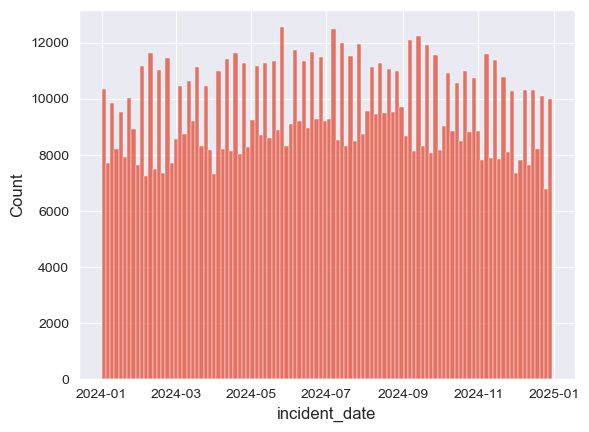

In [236]:
nibrs_df = (
    nibrs_df
        [lambda x: x.incident_date.between(datetime(2024,1,1), datetime(2024,12,31), inclusive="both")]
        .sort_values(by="incident_date")
)
sns.histplot(data=nibrs_df, x="incident_date")
plt.show()

# Fixing UOF ORIs

In [237]:
print(incidents_df["ori"].isna().sum())
incidents_df[lambda x: x.ori.isna()]["state"].value_counts().plot(kind="bar")

47777


In [238]:
incidents_df[incidents_df["ori"].isna()]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE
127231,2024-01-01,75,NaN,NY,PBBN,black,39.0000,male,Physical Force,N,['2024094962018'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024094962018.0000,Physical Force,01/01/2024,75.0000,PBBN,2024 Jan,VTL INFRACTION,No Injury,N,39.0000,BLACK,MALE,Phys

## Matching Agency Name ORIs

In [239]:
incidents_df[incidents_df["ori"].isna()]["agency_name"].unique()[-10:]

array(['66', 'Southampton Vg PD', 'Rye City PD', 'Byesville',
       'SUNY Police - Morrisville', 'Willing Town PD', 'London', 116,
       '116', 'Hartville'], dtype=object)

In [240]:
incidents_df["agency_name"] = incidents_df["agency_name"].astype(str)
incidents_df[incidents_df["ori"].isna()]["agency_name"].unique()[-10:]

<StringArray>
['Hudson Co Prosecutors Office',                   'New Boston',
            'Southampton Vg PD',                  'Rye City PD',
                    'Byesville',    'SUNY Police - Morrisville',
              'Willing Town PD',                       'London',
                          '116',                    'Hartville']
Length: 10, dtype: str

In [241]:
incidents_df["agency_name"].nunique()

1523

In [242]:
agency_info_df = pd.read_csv("./data/agency_info_2024.csv") 
agency_info_df = agency_info_df[lambda x: x.state_abb.isin(states_of_interest)]
print(agency_info_df.shape)
all_oris_df = pd.read_csv("./data/all oris 2024.csv")
all_oris_df = all_oris_df[lambda x: x.state_abbr.isin(states_of_interest)]
print(all_oris_df.shape)

(2112, 13)
(2573, 15)


In [243]:
agency_info_df

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude
804,CA00100,CA0010000,alameda,CA,6.0000,1.0000,6001.0000,99001.0000,sheriffs office,alameda county sheriff's office,alameda county,-121.9133,37.6481
805,CA00101,CA0010100,alameda,CA,6.0000,1.0000,6001.0000,562.0000,local police department,alameda police department,alameda city,-121.9133,37.6481
806,CA00102,CA0010200,albany,CA,6.0000,1.0000,6001.0000,674.0000,local police department,albany police department,albany city,-121.9133,37.6481
807,CA00103,CA0010300,berkeley,CA,6.0000,1.0000,6001.0000,6000.0000,local police department,berkeley police department,berkeley city,-121.9133,37.6481
808,CA00104,CA0010400,emeryville,CA,6.0000,1.0000,6001.0000,22594.0000,local police department,emeryville police department,emeryville city,-121.9133,37.6481
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9205,OH08802,OH0880200,upper sandusky,OH,39.0000,175.0000,39175.0000,79044.0000,local police department,upper sandusky police department,upper sandusky city,-83.3132,40.8401
9206,OHCIP00,OHCIP0000,cincinnati,OH,39.0000,61.0000,39061.0000,15000.0000,local police department,cincinnati police department,cincinnati city,-84.5442,39.1969
9207,OHCLP00,OHCLP0000,cleveland,OH,39.0000,35.0000,39035.0000,16000.0000,local police department,cleveland police department,cleveland city,-81.7242,41.7604
9208,OHCOP00,OHCOP0000,columbus,OH,39.0000,49.0000,39049.0000,18000.0000,local police department,columbus police department,columbus city,-83.0069,39.9696


In [244]:
all_oris_df[lambda x: x.AGENCYNAME.str.contains("HACKENSACK")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat
8815,NJ0022300,BERGEN,True,40.8856,-74.0438,NJ,New Jersey,Hackensack Police Department,City,2021-01-01,HACKENSACK POLICE DEPARTMENT,NJ00223,Local Police,Local police,Local police
8851,NJ0025900,BERGEN,True,40.8601,-74.0455,NJ,New Jersey,South Hackensack Township Police Department,City,2022-01-01,SOUTH HACKENSACK POLICE DEPARTMENT,NJ00259,Local Police,Local police,Local police


In [245]:
unique_norm_ag_names = incidents_df[incidents_df["ori"].isna()]["agency_name"].str.lower().str.replace("pd", "", regex=False).str.strip().unique()
unique_norm_agencyinfo_names = agency_info_df["agency_name"].str.lower().str.replace("pd", "", regex=False).str.strip().unique()

count_in_agencyinfo = sum([name in unique_norm_agencyinfo_names for name in unique_norm_ag_names])
print(f"Number of unique normalized agency names in incidents_df found in agency_info_df: {count_in_agencyinfo} out of {len(unique_norm_ag_names)}")

Number of unique normalized agency names in incidents_df found in agency_info_df: 427 out of 1056


In [246]:
not_found_agencies = [name for name in unique_norm_ag_names if name not in unique_norm_agencyinfo_names]
print("Agency names in incidents_df not found in agency_info_df:")
not_found_agencies

Agency names in incidents_df not found in agency_info_df:


['75',
 '40',
 'brick twp',
 'holmdel',
 '120',
 'maple shade',
 '76',
 '81',
 'state parole board',
 '33',
 '46',
 '84',
 '25',
 '113',
 '110',
 '115',
 'new jersey transit police',
 'stone harbor boro',
 '42',
 'willingboro',
 '104',
 '71',
 '17',
 '73',
 'mount holly',
 '49',
 '13',
 'port authority ny-nj',
 'potsdam vg',
 'freeport vg',
 'hamilton twp',
 'putnam county sheriff',
 'new york state police',
 'elmira city',
 'delhi vg',
 'corning city',
 'chemung county sheriff',
 'new york city metro transportation authority',
 'woodbridge twp',
 'onondaga county sheriff',
 '14',
 '94',
 'montville twp',
 '50',
 '101',
 '105',
 '67',
 'saratoga county sheriff',
 'schenectady city',
 'suffolk county',
 'auburn city',
 'amsterdam city',
 'suny police - upstate medical',
 'syracuse city',
 '114',
 'new york city police department',
 'niagara county sheriff',
 'ohio state highway patrol',
 'edison twp',
 'niagara falls city',
 '108',
 'essex co sheriffs office',
 'middlesex boro',
 '52',


In [247]:
# agency-type suffixes to strip from both sides
_agency_suffixes = (
    r"\s*(department|dept\.?|division|office)\s*$"
)
# location-type words to strip from both sides after expansion
_location_suffixes = r"\s*(borough|township|village|city|county|town)\s*$"

police_abb_mapping = {
    "pd":   "police",
    "twp":  "township",
    "boro": "borough",
    "vg":   "village",
    "co":   "county",
    "mta":  "metropolitan transit authority",
    "rta":  "regional transit authority",
}

def normalize_agency_name(s):
    s = s.str.lower().str.strip()
    # expand abbreviations
    for abbr, full in police_abb_mapping.items():
        s = s.str.replace(r"\b" + abbr + r"\b", full, regex=True)
    # strip agency-type suffix
    s = s.str.replace(_agency_suffixes, "", regex=True).str.strip()
    # strip trailing location-type word
    s = s.str.replace(_location_suffixes, "", regex=True).str.strip()
    # clean punctuation (apostrophes, periods, hyphens)
    s = s.str.replace(r"['.\-]", "", regex=True)
    # normalize sheriffs -> sheriff (apostrophe drop from "sheriff's" leaves trailing s)
    s = s.str.replace(r"\bsheriffs\b", "sheriff", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

In [248]:
incidents_df["agency_name_norm"] = normalize_agency_name(incidents_df["agency_name"])
all_oris_df["AGENCYNAME_norm"] = normalize_agency_name(all_oris_df["AGENCYNAME"])
all_oris_df["agency_name_norm"] = normalize_agency_name(all_oris_df["agency_name"])
agency_info_df["agency_name_norm"] = normalize_agency_name(agency_info_df["agency_name"])

In [249]:
incidents_df["agency_name"]

206455         SAN DIEGO PD
224030          REDLANDS PD
224028         MONTCLAIR PD
206728         SAN DIEGO PD
206737         SAN DIEGO PD
                ...        
228221    CHP-HQ A/C, STAFF
161087      Amherst Town PD
192698    Suffolk County PD
153975                   47
228233    CHP-HQ A/C, STAFF
Name: agency_name, Length: 84152, dtype: str

In [250]:
no_ori = incidents_df[incidents_df["ori"].isna()]
unique_pairs = no_ori[["agency_name_norm", "state"]].drop_duplicates()

# pass 1: strict match on full normalized name (preserves police vs sheriff distinction)
ori_name_state_set = (
    set(zip(all_oris_df["AGENCYNAME_norm"], all_oris_df["state_abbr"]))
    | set(zip(all_oris_df["agency_name_norm"], all_oris_df["state_abbr"]))
    | set(zip(agency_info_df["agency_name_norm"], agency_info_df["state_abb"]))
)
pass1_matched = {(n, s) for n, s in unique_pairs.itertuples(index=False) if (n, s) in ori_name_state_set}
pass1_unmatched = [(n, s) for n, s in unique_pairs.itertuples(index=False) if (n, s) not in ori_name_state_set]

# pass 2: strip trailing "police"/"sheriff" and only accept if unique agency in that state
_agency_qualifier = r"\s*(police|sheriff)\s*$"

ori_base = pd.concat([
    all_oris_df[["AGENCYNAME_norm", "state_abbr"]].rename(columns={"AGENCYNAME_norm": "name_norm"}),
    all_oris_df[["agency_name_norm", "state_abbr"]].rename(columns={"agency_name_norm": "name_norm"}),
    agency_info_df[["agency_name_norm", "state_abb"]].rename(columns={"agency_name_norm": "name_norm", "state_abb": "state_abbr"}),
]).drop_duplicates()
ori_base["name_base"] = ori_base["name_norm"].str.replace(_agency_qualifier, "", regex=True).str.strip()
base_counts = ori_base.groupby(["name_base", "state_abbr"]).size()

pass2_matched = []
still_unmatched = []
for name, state in pass1_unmatched:
    base = re.sub(_agency_qualifier, "", name).strip()
    if base_counts.get((base, state), 0) == 1:
        pass2_matched.append((name, state))
    else:
        still_unmatched.append((name, state))

total_matched = len(pass1_matched) + len(pass2_matched)
print(f"Unique (agency_name_norm, state) pairs with no ORI: {len(unique_pairs)}")
print(f"Pass 1 (strict):   {len(pass1_matched)}")
print(f"Pass 2 (fallback): {len(pass2_matched)}")
print(f"Total matched:     {total_matched} out of {len(unique_pairs)}")

Unique (agency_name_norm, state) pairs with no ORI: 1061
Pass 1 (strict):   851
Pass 2 (fallback): 25
Total matched:     876 out of 1061


In [251]:
print(f"Still unmatched ({len(still_unmatched)}):")
still_unmatched

Still unmatched (185):


[('75', 'NY'),
 ('40', 'NY'),
 ('120', 'NY'),
 ('76', 'NY'),
 ('81', 'NY'),
 ('state parole board', 'NJ'),
 ('33', 'NY'),
 ('46', 'NY'),
 ('84', 'NY'),
 ('25', 'NY'),
 ('113', 'NY'),
 ('110', 'NY'),
 ('115', 'NY'),
 ('42', 'NY'),
 ('104', 'NY'),
 ('71', 'NY'),
 ('17', 'NY'),
 ('73', 'NY'),
 ('49', 'NY'),
 ('13', 'NY'),
 ('port authority nynj police', 'NY'),
 ('new york state police', 'NY'),
 ('elmira city police', 'NY'),
 ('new york city metro transportation authority', 'NY'),
 ('14', 'NY'),
 ('94', 'NY'),
 ('50', 'NY'),
 ('101', 'NY'),
 ('105', 'NY'),
 ('67', 'NY'),
 ('suny police upstate medical', 'NY'),
 ('114', 'NY'),
 ('108', 'NY'),
 ('52', 'NY'),
 ('44', 'NY'),
 ('10', 'NY'),
 ('19', 'NY'),
 ('60', 'NY'),
 ('69', 'NY'),
 ('7', 'NY'),
 ('61', 'NY'),
 ('88', 'NY'),
 ('62', 'NY'),
 ('90', 'NY'),
 ('18', 'NY'),
 ('43', 'NY'),
 ('delaware river port authority', 'NJ'),
 ('77', 'NY'),
 ('mt ephraim police', 'NJ'),
 ('34', 'NY'),
 ('wanaque borough police', 'NJ'),
 ('lindenwold borough p

In [252]:
# build (name_norm, state_abbr) -> ori lookup from both name columns
lookup_df = pd.concat([
    all_oris_df[["AGENCYNAME_norm", "state_abbr", "ori"]].rename(columns={"AGENCYNAME_norm": "name_norm"}),
    all_oris_df[["agency_name_norm", "state_abbr", "ori"]].rename(columns={"agency_name_norm": "name_norm"}),
    agency_info_df[["agency_name_norm", "state_abb", "ori9"]].rename(columns={"agency_name_norm": "name_norm", "state_abb": "state_abbr", "ori9": "ori"}),
]).drop_duplicates(subset=["name_norm", "state_abbr"])

# pass 1: merge on full normalized name + state
mask = incidents_df["ori"].isna()
p1_result = incidents_df.loc[mask, ["agency_name_norm", "state"]].merge(
    lookup_df,
    left_on=["agency_name_norm", "state"],
    right_on=["name_norm", "state_abbr"],
    how="left"
)
incidents_df.loc[mask, "ori"] = p1_result["ori"].values
print(f"Pass 1 filled: {mask.sum() - incidents_df['ori'].isna().sum()}")

# pass 2: strip trailing police/sheriff, accept only if unique agency in state
mask2 = incidents_df["ori"].isna()

base_lookup = (
    ori_base[ori_base.groupby(["name_base", "state_abbr"])["name_base"].transform("count") == 1]
    .drop_duplicates(subset=["name_base", "state_abbr"])
    .merge(lookup_df, on=["name_norm", "state_abbr"], how="left")
    [["name_base", "state_abbr", "ori"]]
)

incidents_df.loc[mask2, "name_base_temp"] = (
    incidents_df.loc[mask2, "agency_name_norm"]
    .str.replace(_agency_qualifier, "", regex=True).str.strip()
)
p2_result = incidents_df.loc[mask2, ["name_base_temp", "state"]].merge(
    base_lookup,
    left_on=["name_base_temp", "state"],
    right_on=["name_base", "state_abbr"],
    how="left"
)
incidents_df.loc[mask2, "ori"] = p2_result["ori"].values
incidents_df.drop(columns=["name_base_temp"], inplace=True)

print(f"Pass 2 filled: {mask2.sum() - incidents_df['ori'].isna().sum()}")
print(f"Still missing ORI: {incidents_df['ori'].isna().sum()}")

Pass 1 filled: 30853
Pass 2 filled: 1474
Still missing ORI: 15450


## Adding NYC ORIs

In [253]:
incidents_df[lambda x: x.ori.isna()]["state"].value_counts().plot(kind="bar")

In [254]:
incidents_df[lambda x: (x.state=="NY") & (x.ori.isna())]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
127231,2024-01-01,75,NaN,NY,PBBN,black,39.0000,male,Physical Force,N,['2024094962018'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024094962018.0000,Physical Force,01/01/2024,75.0000,PBBN,2024 Jan,VTL INFRACTION,No Injury,N,39.000

In [255]:
agency_info_df[lambda x: (x.state_abb == "NY") & (x.census_name == "new york city")]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm
8361,NY03030,NY0303000,new york,NY,36.0000,61.0000,36061.0000,51000.0000,local police department,new york city police department,new york city,-73.9702,40.7766,new york


In [256]:
nyc_ori = agency_info_df[lambda x: (x.state_abb == "NY") & (x.census_name == "new york city")]["ori9"].item()

In [257]:
nyc_ori

'NY0303000'

In [258]:
mask_nyc_number_agency = (
    (incidents_df["state"] == "NY")
    & (incidents_df["ori"].isna())
    & (
        incidents_df["agency_name"]
        .apply(lambda v: False if pd.isna(v) else str(v).isdigit())
    )
)
incidents_df.loc[mask_nyc_number_agency, "ori"] = nyc_ori

In [259]:
incidents_df[lambda x: (x.state=="NY") & (x.ori.isna())]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
185005,2024-01-01,Port Authority NY-NJ PD,NaN,NY,"New York, New York",black,54.0000,male,Used/Deployed Chemical Agent,NaN,20232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202

In [260]:
print(f"Still missing ORI: {incidents_df['ori'].isna().sum()}")

Still missing ORI: 2775


In [261]:
incidents_df[lambda x: x.ori.isna()]["state"].value_counts().plot(kind="bar")

## Manually Fixing Other ORIs

In [262]:
## TODO: MANUALLY FIX THE REST OF THE ORIs
incidents_df[incidents_df["ori"].isna()]["agency_name_norm"].value_counts()

agency_name_norm
new york state police                                           983
elmira city police                                              212
delaware river port authority                                   210
new york city metro transportation authority                    117
state parole board                                              111
rutgers university police                                       107
westchester county dept pub safety                               58
woodbury city police                                             53
nj state human services                                          50
niagara frontier transportation authority police                 46
port authority nynj police                                       38
white plains city police                                         38
lindenwold borough police                                        31
clementon borough police                                         29
totowa borough police          

In [263]:
incidents_df[incidents_df["ori"].isna()]["agency_name_norm"].value_counts().shape

(110,)

In [264]:
agency_info_df[lambda x: (x.state_abb == "NY")]["agency_type"].value_counts()

agency_type
local police department    340
sheriffs office             54
special jurisdiction        27
Name: count, dtype: int64

In [265]:
all_oris_df[lambda x: (x.state_abbr == "NY")]["agency_cat"].value_counts()

agency_cat
Local police    415
State police     67
Sheriff          56
Name: count, dtype: int64

In [266]:
all_oris_df[lambda x: (x.state_abbr == "NY") & (x.agency_cat == "State police")& (x.agency_type_nominal == "Primary State Police")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
9401,NY314SA00,ERIE,False,43.0292,-78.1901,NY,New York,State Police: Erie County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: erie
9420,NY315SB00,ESSEX,False,44.1090,-73.7776,NY,New York,State Police: Essex County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: essex
9424,NY324SD00,LEWIS,False,43.7827,-75.4441,NY,New York,State Police: Lewis County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: lewis
9425,NY353SC00,TIOGA,False,42.1781,-76.2975,NY,New York,State Police: Tioga County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: tioga
9436,NY358SE00,WAYNE,False,42.9571,-77.3429,NY,New York,State Police: Wayne County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: wayne
9438,NY361SE00,YATES,False,42.9571,-77.3429,NY,New York,State Police: Yates County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: yates
9447,NY301SG00,ALBANY,False,42.7161,-73.7554,NY,New York,State Police: Albany County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: albany
9456,NY303SC00,BROOME,False,42.1620,-75.8303,NY,New York,State Police: Broome County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: broome
9464,NY305SE00,CAYUGA,False,43.0085,-76.5746,NY,New York,State Police: Cayuga County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: cayuga
9467,NY317SG00,FULTON,False,42.7161,-73.7554,NY,New York,State Police: Fulton County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: fulton


In [267]:
all_oris_df[lambda x: x.ori == "NY0303000"]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
9965,NY0303000,NOT SPECIFIED,True,40.7766,-73.9702,NY,New York,New York City Police Department,City,2023-01-01,NEW YORK CITY POLICE DEPARTMENT,NY03030,Local Police,Local police,Local police,new york city police,new york city police


## Looking at State Agency ORIs and Phantom ORIs

### State Agency ORIs

In [268]:
all_oris_df["agency_cat"].value_counts()

agency_cat
Local police    2042
Sheriff          223
State police     152
Name: count, dtype: int64

In [269]:
all_oris_df["agency_type_name"].value_counts()

agency_type_name
City                     2038
County                    226
University or College     111
State Police               82
Other                      71
Other State Agency         45
Name: count, dtype: int64

In [270]:
all_oris_df["agency_type_nominal"].value_counts()

agency_type_nominal
Local police            2020
Sheriff                  223
Special Purpose          132
College/University       112
Primary State Police      82
K-12 Public School         4
Name: count, dtype: int64

#### CA State Police

In [271]:
all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "CA")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
1206,CA0349900,SACRAMENTO,True,38.5857,-121.4956,CA,California,Highway Patrol: Sacramento County,State Police,2021-11-01,CALIFORNIA HIGHWAY PATROL,CA03499,Primary State Police,Primary State Police,State police,california highway patrol,highway patrol: sacramento


In [272]:
all_oris_df[lambda x: (x.agency_name.str.lower().str.contains("highway")) & (x.state_abbr == "CA")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
1206,CA0349900,SACRAMENTO,True,38.5857,-121.4956,CA,California,Highway Patrol: Sacramento County,State Police,2021-11-01,CALIFORNIA HIGHWAY PATROL,CA03499,Primary State Police,Primary State Police,State police,california highway patrol,highway patrol: sacramento


In [273]:
agency_info_df["agency_type"].value_counts()

agency_type
local police department         1627
sheriffs office                  200
special jurisdiction             161
state law enforcement agency      77
constable/marshal                  1
Name: count, dtype: int64

In [274]:
agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "CA")]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm
821,CA00199,CA0019900,hp: golden gate investig,CA,6.0000,1.0000,6001.0000,33000.0000,state law enforcement agency,chp hayward,state of california,-121.9133,37.6481,hp: golden gate investig
827,CA00399,CA0039900,hp: amador area office,CA,6.0000,5.0000,6005.0000,1514.0000,state law enforcement agency,chp amador,state of california,-120.6539,38.4436,hp: amador area
836,CA00499,CA0049900,hp: oroville area office,CA,6.0000,7.0000,6007.0000,13014.0000,state law enforcement agency,chp chico,state of california,-121.6019,39.6660,hp: oroville area
841,CA00599,CA0059900,hp: san andreas area off,CA,6.0000,9.0000,6009.0000,64420.0000,state law enforcement agency,chp san andreas,state of california,-120.5594,38.1846,hp: san andreas area off
845,CA00699,CA0069900,hp: williams area office,CA,6.0000,11.0000,6011.0000,85586.0000,state law enforcement agency,chp williams,state of california,-122.2376,39.1777,hp: williams area
868,CA00799,CA0079900,hp: contra costa area of,CA,6.0000,13.0000,6013.0000,99013.0000,state law enforcement agency,chp contra costa,state of california,-121.9515,37.9195,hp: contra costa area of
871,CA00899,CA0089900,hp: crescent city area o,CA,6.0000,15.0000,6015.0000,17022.0000,state law enforcement agency,chp crescent city,state of california,-123.9810,41.7499,hp: crescent city area o
876,CA00999,CA0099900,hp: placerville area off,CA,6.0000,17.0000,6017.0000,57540.0000,state law enforcement agency,chp placerville,state of california,-120.5344,38.7855,hp: placerville area off
879,CA01019,CA0101900,california department of,CA,6.0000,19.0000,6019.0000,99019.0000,state law enforcement agency,spt fresno,state of california,-119.6550,36.7610,california department of
881,CA01099,CA0109900,hp: central division,CA,6.0000,19.0000,6019.0000,27000.0000,state law enforcement agency,chp fresno,state of california,-119.6550,36.7610,hp: central


In [275]:
cali_state_police_oris = agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "CA")]["ori9"]
cali_state_police_oris

821     CA0019900
827     CA0039900
836     CA0049900
841     CA0059900
845     CA0069900
868     CA0079900
871     CA0089900
876     CA0099900
879     CA0101900
881     CA0109900
883     CA0119900
893     CA0129900
901     CA0139900
904     CA0149900
917     CA0159900
923     CA0169900
927     CA0179900
930     CA0189900
979     CA0199900
984     CA0209900
991     CA0219900
994     CA0229900
999     CA0239900
1008    CA0249900
1011    CA0259900
1014    CA0269900
1030    CA0279900
1038    CA0289900
1043    CA0299900
1081    CA0309900
1088    CA0319900
1089    CA0329900
1106    CA0339900
1123    CA0349900
1139    CA0369900
1162    CA0379900
1173    CA0389900
1184    CA0399900
1196    CA0409900
1215    CA0419900
1220    CA0429900
1237    CA0439900
1246    CA0449900
1252    CA0459900
1265    CA0479900
1274    CA0489900
1290    CA0499900
1297    CA0509900
1300    CA0519900
1305    CA0529900
1307    CA0539900
1318    CA0549900
1321    CA0559900
1338    CA0569900
1343    CA0579900
Name: ori9

##### UOF Data

In [276]:
incidents_df[lambda x: x.ori.isin(cali_state_police_oris)]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm


In [277]:
incidents_df[lambda x: x.CALI_AGENCY_ORI.isin(cali_state_police_oris)]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm


In [278]:
incidents_df[lambda x: x.CALI_AGENCY_NAME.str.lower().str.contains("highway")]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm


##### NIBRS Data

In [279]:
nibrs_df[lambda x: x.ori.isin(cali_state_police_oris)]["ori"]

3195206    CA0349900
3195047    CA0349900
3195041    CA0349900
3195044    CA0349900
3194972    CA0349900
             ...    
3195202    CA0349900
3195140    CA0349900
3195135    CA0349900
3195134    CA0349900
3194962    CA0349900
Name: ori, Length: 823, dtype: str

In [280]:
nibrs_df[lambda x: x.ori.isin(cali_state_police_oris)]["ori"].value_counts()

ori
CA0349900    822
CA0101900      1
Name: count, dtype: int64

In [281]:
nibrs_df[lambda x: x.state_abbr == "CA"].shape

(500768, 21)

In [282]:
nibrs_df[lambda x: x.ori.isin(cali_state_police_oris)].head()

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
3195206,4,CA0349900,NZ-F1284KI M,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,28,male,U,NaN,1,CA,California,white
3195047,4,CA0349900,35-R6-FCZ78I,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,27,female,U,NaN,1,CA,California,hispanic
3195041,4,CA0349900,35-R6-FC0W4I,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,40,male,U,NaN,1,CA,California,hispanic
3195044,4,CA0349900,35-R6-FCT36I,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,29,female,U,NaN,1,CA,California,black
3194972,4,CA0349900,2K-QTU72S4BA,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,20,male,U,NaN,1,CA,California,hispanic


In [283]:
nibrs_df[lambda x: x.ori.isin(cali_state_police_oris)]["incident_date"].plot(kind="bar")

##### Why are there such few hits?

In [284]:
incidents_df["state"].value_counts()

state
CA    36375
NY    24547
NJ    19972
OH     3258
Name: count, dtype: int64

In [285]:
incidents_df[lambda x: x.state == "CA"]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
206455,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [286]:
# Get all ORIs for CA from incidents_df
ca_incident_oris = incidents_df[lambda x: x.state == "CA"]["ori"].unique()
print(len(ca_incident_oris))
agency_info_df[lambda x: (x.ori9.isin(ca_incident_oris))].shape

461


(365, 14)

In [287]:
all_oris_df[lambda x: (x.ori.isin(ca_incident_oris))].shape

(414, 17)

In [288]:
all_oris_df[lambda x: (x.ori.isin(ca_incident_oris))].head()

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
843,CA0140000,INYO,True,36.5620,-117.4039,CA,California,Inyo County Sheriff's Office,County,2022-12-01,INYO COUNTY SHERIFF'S OFFICE,CA01400,Sheriff,Sheriff,Sheriff,inyo county sheriff,inyo county sheriff
844,CA0140100,INYO,True,37.3614,-118.3964,CA,California,Bishop Police Department,City,2022-12-01,BISHOP POLICE DEPARTMENT,CA01401,Local Police,Local police,Local police,bishop police,bishop police
845,CA0150000,KERN,False,35.4196,-119.0474,CA,California,Kern County Sheriff's Office,County,NaN,KERN COUNTY SHERIFF'S OFFICE,CA01500,Sheriff,Sheriff,Sheriff,kern county sheriff,kern county sheriff
847,CA0150200,KERN,True,35.3466,-118.7295,CA,California,Bakersfield Police Department,City,2022-09-01,BAKERSFIELD POLICE DEPARTMENT,CA01502,Local Police,Local police,Local police,bakersfield police,bakersfield police
848,CA0150300,KERN,True,35.3466,-118.7295,CA,California,Delano Police Department,City,2021-12-01,DELANO POLICE DEPARTMENT,CA01503,Local Police,Local police,Local police,delano police,delano police


In [289]:
all_oris_df[lambda x: (x.ori.isin(ca_incident_oris))]["agency_cat"].value_counts()

agency_cat
Local police    318
Sheriff          55
State police      6
Name: count, dtype: int64

In [290]:
all_oris_df[lambda x: (x.ori.isin(ca_incident_oris)) & (x.agency_cat == "State police")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
1034,CA0012100,ALAMEDA,False,37.7974,-122.2666,CA,California,San Francisco Bay Area Rapid Transit: Alameda ...,Other,NaN,BART POLICE DEPARTMENT,CA00121,Mass Transit,Special Purpose,State police,bart police,san francisco bay area rapid transit: alameda
1037,CA0011400,ALAMEDA,True,37.7138,-122.1004,CA,California,East Bay Regional Parks: Alameda County,Other,2022-04-01,EAST BAY REGIONAL PARKS DISTRICT POLICE DEPART...,CA00114,Parks and Recreational Areas,Special Purpose,State police,east bay regional parks district police,east bay regional parks: alameda
1162,CA0371500,SAN DIEGO,True,32.7294,-117.1951,CA,California,Port of San Diego Harbor,Other,2021-01-01,PORT OF SAN DIEGO HARBOR POLICE DEPARTMENT,CA03715,Harbor/Port Facilities,Local police,State police,port of san diego harbor police,port of san diego harbor
1207,CA0341400,SACRAMENTO,True,38.6517,-121.3896,CA,California,Twin Rivers Unified School District,Other,2022-04-01,TWIN RIVERS UNIFIED SCHOOL DISTRICT POLICE DEP...,CA03414,K-12 Public School,K-12 Public School,State police,twin rivers unified school district police,twin rivers unified school district
1339,CA0391500,SAN JOAQUIN,True,37.9663,-121.2907,CA,California,Stockton Unified School District,Other,2022-01-01,STOCKTON UNIFIED SCHOOL DISTRICT POLICE DEPART...,CA03915,K-12 Public School,K-12 Public School,State police,stockton unified school district police,stockton unified school district
1420,CA0362300,SAN BERNARDINO,True,34.1214,-117.2951,CA,California,San Bernardino Unified School District,Other,2021-10-01,SAN BERNARDINO CITY UNIFIED SCHOOL DISTRICT PO...,CA03623,K-12 Public School,K-12 Public School,State police,san bernardino city unified school district po...,san bernardino unified school district


In [291]:
incidents_df[lambda x: x.CALI_AGENCY_NAME.str.lower().str.contains("chp")]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
221929,2024-01-01,"CHP-HQ A/C, STAFF",CA0349902,CA,CHP,black,25,male,CALI_OFA_ELECT_DEVICE_STUN | CALI_OFA_PHYSICAL...,NaN,['W349925058GA6OATV19J'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [292]:
incidents_df[lambda x: x.CALI_AGENCY_NAME.str.lower().str.contains("chp")]["ori"].value_counts()

ori
CA0349902    1765
Name: count, dtype: int64

In [293]:
nibrs_df

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
448429,4,CA0540500,CEPBROZR728N,2024-01-01,1,24AR0021,T,N,35A,1,NaN,NaN,NaN,33,female,NaN,NaN,0,CA,California,hispanic
390207,4,CA0390500,CE0BRVZCS28N,2024-01-01,1,2400017,O,N,13A,1,NaN,NaN,NaN,28,male,U,NaN,0,CA,California,hispanic
343897,4,CA0360200,CE0BRVRU728N,2024-01-01,2,47809,O,N,35A,1,NaN,NaN,NaN,60,male,N,NaN,0,CA,California,black
343896,4,CA0360200,CE0BRVRU728N,2024-01-01,1,47808,O,N,35A,1,NaN,NaN,NaN,19,male,N,NaN,0,CA,California,white
3176982,4,CA0310000,AV2ZPU72UD1A,2024-01-01,1,NaN,T,NaN,90Z,1,NaN,NaN,NaN,27,male,R,NaN,1,CA,California,hispanic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1906776,34,OH0040000,UJ-8N0WHSCTD,2024-12-31,1,24-22339,T,C,13B,1,NaN,NaN,NaN,37,male,R,NaN,0,OH,Ohio,white
1906834,34,OH0040000,ZJ-J4KOB-F39,2024-12-31,1,25-00002,T,C,13B,1,NaN,NaN,NaN,38,male,R,NaN,0,OH,Ohio,white
186122,4,CA0070400,UJ-AOMJHSCTD,2024-12-31,1,AR2024-03719,O,N,35A,1,NaN,NaN,NaN,36,male,N,NaN,0,CA,California,white
4444811,34,OH0184600,Z82B4IOBBF39,2024-12-31,1,NaN,T,NaN,90Z,1,NaN,NaN,NaN,60,male,R,NaN,1,OH,Ohio,white


What is this ORI? CA0349902

In [294]:
chp_oris = incidents_df[lambda x: x.CALI_AGENCY_NAME.str.lower().str.contains("chp")]["ori"].unique()
chp_oris

<StringArray>
['CA0349902']
Length: 1, dtype: str

In [295]:
all_oris_df[lambda x: (x.ori.isin(chp_oris))]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm


In [296]:
agency_info_df[lambda x: (x.ori9.isin(chp_oris))]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm


In [297]:
agency_info_df[lambda x: (x.ori == "CA03499")]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm
1123,CA03499,CA0349900,hp: sacramento county,CA,6.0000,67.0000,6067.0000,99067.0000,state law enforcement agency,highway patrol: sacramento county,NaN,121.3893,38.5611,hp: sacramento


In [298]:
incidents_df[lambda x: x.ori.str.contains("CA03499")]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
221929,2024-01-01,"CHP-HQ A/C, STAFF",CA0349902,CA,CHP,black,25,male,CALI_OFA_ELECT_DEVICE_STUN | CALI_OFA_PHYSICAL...,NaN,['W349925058GA6OATV19J'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [299]:
incidents_df[lambda x: x.state == "CA"].shape

(36375, 177)

In [300]:
nibrs_df[lambda x: x.ori.str.contains("CA03499")]

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
3195206,4,CA0349900,NZ-F1284KI M,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,28,male,U,NaN,1,CA,California,white
3195047,4,CA0349900,35-R6-FCZ78I,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,27,female,U,NaN,1,CA,California,hispanic
342007,4,CA0349917,WJ2KKDCSN0W5,2024-01-01,1,24-AR002919,T,N,35B,1,NaN,NaN,NaN,40,male,U,NaN,0,CA,California,white
3196331,4,CA0349950,NZ-F1284KDIM,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,30,female,U,NaN,1,CA,California,black
3195041,4,CA0349900,35-R6-FC0W4I,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,40,male,U,NaN,1,CA,California,hispanic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195202,4,CA0349900,NU-F1284JIZM,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,38,male,U,NaN,1,CA,California,hispanic
3195140,4,CA0349900,3M-R6-FCUW5I,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,35,male,U,NaN,1,CA,California,white
3195135,4,CA0349900,3M-R6-FCP73I,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,25,male,U,NaN,1,CA,California,asian
3195134,4,CA0349900,3M-R6-FCNU6I,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,65,male,U,NaN,1,CA,California,hispanic


In [301]:
nibrs_df[lambda x: x.ori.str.contains("CA03499")]["ori"].value_counts()

ori
CA0349950    920
CA0349900    822
CA0349952    768
CA0349917    420
CA0349960    376
CA0349901     36
CA0349923      2
CA0349908      1
CA0349912      1
Name: count, dtype: int64

##### Cali CHP ORIs
TODO: verify eff data source
https://www.eff.org/files/2015/11/18/pra-request_clets_agencies_04282015.xls

In [302]:
cali_oris_xlsx = pd.read_excel("./data/pra-request_clets_agencies_04282015.xls", engine="xlrd")
display(cali_oris_xlsx)

,ORI,AAA,Agency Short name,Agency Name
0,AZINS0200,G69,US BORDER PATROL-YUMA,US BORDER PATROL-YUMA SECTOR
1,CA0010000,104,ALAMEDA CO SO,ALAMEDA COUNTY SHERIFFS OFFICE
2,CA0010002,104,ALAMEDA CO SO-NCOJAIL,ALAMEDA CO SO-NCOJAIL
3,CA0010003,104,ALAMEDA CO SO-NCOJAIL,ALAMEDA CO SO-NCOJAIL
4,CA0010004,104,ALAMEDA CO SO-NCOJAIL,ALAMEDA CO SO-NCOJAIL
...,...,...,...,...
5269,OR024015A,J94,OREGON DEPT. OF JUSTICE,OREGON DEPT. OF JUSTICE
5270,OR024015Y,235,OREGON LAW ENFORCEMENT CENTER,OREGON LAW ENFORCEMENT CENTER
5271,OR024025A,A75,OREGON DEPT OF JUSTICE,OREGON DEPT OF JUSTICE
5272,OR0SP0000,B73,OREGON STATE POLICE,OREGON STATE POLICE


In [303]:
cali_oris_xlsx[lambda x: (x["Agency Short name"].str.lower().str.contains("chp")) 
                        | (x["Agency Short name"].str.lower().str.contains("california highway patrol"))].shape

(292, 4)

In [304]:
cali_oris_xlsx[lambda x: (x["Agency Short name"].str.lower().str.contains("chp")) 
                        | (x["Agency Short name"].str.lower().str.contains("california highway patrol"))].head(10)

,ORI,AAA,Agency Short name,Agency Name
142,CA0019800,F12,CHP-GOLDEN GATE COMM CTR,CALIF STATE POLICE DIV
143,CA0019900,120,CHP-HAYWARD #2,CHP-GOLDEN GATE COMMUNICATION CNTR
144,CA0019916,120,CHP-GG INVEST SERVICES,CHP-GOLDEN GATE INVESTIGATIION SVCS
145,CA0019917,120,CHP-GG INVESTIGATION SVCS,CHP-GOLDEN GATE INVES SERVICES
146,CA0019918,120,CHP GOLDEN GATE CC,CHP GOLDEN GATE CC
147,CA0019945,120,CHP-HAYWARD,CHP - HAYWARD OFFICE
148,CA0019947,120,CHP-NIMITZ INSP FAC,CHP-NIMITZ INSPECTION FACILITY N/B
149,CA0019948,120,CHP-NIMITZ SCALES,CHP-NIMITZ INSPECTION FACILITY S/B
150,CA0019970,120,CHP-OAKLAND,CHP Z3 OAKLAND
151,CA0019975,120,CHP-CASTRO VALLEY,CHP - CASTRO VALLEY


In [305]:
agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "CA") & (x.ori.str.contains("CA0019"))]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm
821,CA00199,CA0019900,hp: golden gate investig,CA,6.0000,1.0000,6001.0000,33000.0000,state law enforcement agency,chp hayward,state of california,-121.9133,37.6481,hp: golden gate investig


In [306]:
real_cali_chp_oris = (
    cali_oris_xlsx
        [lambda x: (x["Agency Short name"].str.lower().str.contains("chp")) 
                        | (x["Agency Short name"].str.lower().str.contains("california highway patrol"))]
        ["ORI"]
)

In [307]:
real_cali_chp_oris[:5]

142    CA0019800
143    CA0019900
144    CA0019916
145    CA0019917
146    CA0019918
Name: ORI, dtype: str

In [308]:
set(chp_oris).issubset(set(real_cali_chp_oris))

False

In [309]:
real_cali_chp_oris = pd.concat([real_cali_chp_oris, pd.Series(chp_oris)]).drop_duplicates().reset_index(drop=True)

In [310]:
len(real_cali_chp_oris)

293

In [311]:
set(nibrs_df[lambda x: x.ori.str.contains("CA03499")]["ori"].unique()).issubset(set(real_cali_chp_oris))

True

In [312]:
incidents_df[lambda x: x.ori.isin(real_cali_chp_oris)]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
221929,2024-01-01,"CHP-HQ A/C, STAFF",CA0349902,CA,CHP,black,25,male,CALI_OFA_ELECT_DEVICE_STUN | CALI_OFA_PHYSICAL...,NaN,['W349925058GA6OATV19J'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [313]:
len(incidents_df[lambda x: x.state == "CA"])

36375

In [314]:
nibrs_df[lambda x: x.ori.isin(real_cali_chp_oris)]

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
3195206,4,CA0349900,NZ-F1284KI M,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,28,male,U,NaN,1,CA,California,white
3201862,4,CA0369955,2K-QTU7297TA,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,21,male,U,NaN,1,CA,California,hispanic
3201863,4,CA0369955,2K-QTU729G8A,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,46,male,U,NaN,1,CA,California,asian
3176452,4,CA0309990,UJ-ESHPHOP7D,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,47,male,U,NaN,1,CA,California,asian
3267510,4,CA0509965,2K-QTU72720A,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,35,male,U,NaN,1,CA,California,black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3262130,4,CA0499960,2H-QTU7287TA,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,54,male,U,NaN,1,CA,California,black
3262131,4,CA0499960,2H-QTU728XXA,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,32,male,U,NaN,1,CA,California,hispanic
3262998,4,CA0499960,V1-JPB0W5C-2,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,31,male,U,NaN,1,CA,California,white
3262999,4,CA0499960,V1-JPB0W5CT2,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,34,male,U,NaN,1,CA,California,unknown


In [315]:
len(nibrs_df[lambda x: x.state_abbr == "CA"])

500768

##### Aggregating State ORIs

In [316]:
# TODO: find a more specific statewide ORI

In [317]:
all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "CA")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
1206,CA0349900,SACRAMENTO,True,38.5857,-121.4956,CA,California,Highway Patrol: Sacramento County,State Police,2021-11-01,CALIFORNIA HIGHWAY PATROL,CA03499,Primary State Police,Primary State Police,State police,california highway patrol,highway patrol: sacramento


In [318]:
cali_statewide_ori = all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "CA")]["ori"].item()
cali_statewide_ori

'CA0349900'

UOF Data

In [319]:
print(f"before: unique CHP oris = {incidents_df.loc[lambda x: x.ori.isin(real_cali_chp_oris)]["ori"].unique()}")
incidents_df.loc[lambda x: x.ori.isin(real_cali_chp_oris), "ori"]= cali_statewide_ori
print(f"after: unique CHP oris = {incidents_df.loc[lambda x: x.ori.isin(real_cali_chp_oris)]["ori"].unique()}")


before: unique CHP oris = <StringArray>
['CA0349902']
Length: 1, dtype: str
after: unique CHP oris = <StringArray>
['CA0349900']
Length: 1, dtype: str


NIBRS

In [320]:
print(f"before: unique CHP oris = {nibrs_df.loc[lambda x: x.ori.isin(real_cali_chp_oris)]["ori"].unique()}")
nibrs_df.loc[lambda x: x.ori.isin(real_cali_chp_oris), "ori"] = cali_statewide_ori
print(f"after: unique CHP oris = {nibrs_df.loc[lambda x: x.ori.isin(real_cali_chp_oris)]["ori"].unique()}")


before: unique CHP oris = <StringArray>
['CA0349900', 'CA0369955', 'CA0309990', 'CA0509965', 'CA0389935', 'CA0199950',
 'CA0199935', 'CA0109935', 'CA0349917', 'CA0199930',
 ...
 'CA0109901', 'CA0409901', 'CA0299923', 'CA0349908', 'CA0139926', 'CA0349923',
 'CA0339956', 'CA0199910', 'CA0159912', 'CA0349912']
Length: 122, dtype: str
after: unique CHP oris = <StringArray>
['CA0349900']
Length: 1, dtype: str


#### OH State Police

In [321]:
all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "OH")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
11357,OHOHP0000,NOT SPECIFIED,True,39.9696,-83.0069,OH,Ohio,Ohio State Highway Patrol,State Police,2003-01-01,OHIO STATE HIGHWAY PATROL,OHOHP00,Primary State Police,Primary State Police,State police,ohio state highway patrol,ohio state highway patrol


In [322]:
agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "OH")]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm
9209,OHOHP00,OHOHP0000,ohio state highway patro,OH,39.0000,49.0000,39049.0000,18000.0000,state law enforcement agency,ohio state highway patrol,state of ohio,-83.0069,39.9696,ohio state highway patro


In [323]:
ohio_state_police_ori = agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "OH")]["ori9"].item()
ohio_state_police_ori

'OHOHP0000'

##### UOF Data

In [324]:
incidents_df[lambda x: x.agency_name_norm == "ohio state highway patrol"].shape

(341, 177)

In [325]:
incidents_df[lambda x: x.ori == ohio_state_police_ori].shape

(341, 177)

In [326]:
incidents_df[lambda x: x.agency_name.str.lower().str.contains("highway")].shape

(341, 177)

In [327]:
incidents_df[lambda x: x.ori.str.contains("OHOHP00")].shape

(341, 177)

In [328]:
incidents_df[lambda x: x.state == "OH"].shape

(3258, 177)

In [329]:
incidents_df[lambda x: x.ori == (ohio_state_police_ori)].head()

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
97886,2024-01-01,Ohio State Highway Patrol,OHOHP0000,OH,Ohio State Highway Patrol,black,NaN,male,Take Down,Apparent Minor Injury,['247700010377'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ohio State Highway Patrol,247700010377,1/1/2024,Traffic Stop,Street,Deadweight | Failing to Comply to Ver

##### NIBRS Data

In [330]:
nibrs_df[lambda x: x.ori == (ohio_state_police_ori)].shape

(13825, 21)

In [331]:
nibrs_df[lambda x: x.ori.str.contains("OHOHP00")].shape

(13825, 21)

In [332]:
nibrs_df[lambda x: x.state_abbr == "OH"].shape

(145777, 21)

In [333]:
nibrs_df[lambda x: x.ori == (ohio_state_police_ori)].head()

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
1992371,34,OHOHP0000,O 7LJ4KHZKRV,2024-01-01,1,247700010377,O,N,35A,1,NaN,NaN,NaN,46,male,R,NaN,0,OH,Ohio,black
1992239,34,OHOHP0000,O 7284KHZBRL,2024-01-01,1,247990010779,T,N,13A,1,NaN,NaN,NaN,30,female,R,NaN,0,OH,Ohio,white
1992705,34,OHOHP0000,V11I9 ROSRTD,2024-01-01,1,241063010300,O,N,35A,1,NaN,NaN,NaN,47,male,R,NaN,0,OH,Ohio,white
1992753,34,OHOHP0000,V3ZL6X8IX4E,2024-01-01,1,243000010318,O,N,520,1,NaN,NaN,NaN,27,male,R,NaN,0,OH,Ohio,black
1992878,34,OHOHP0000,ZI1K KOPL IS,2024-01-01,1,241520010557,O,N,280,1,NaN,NaN,NaN,31,male,R,NaN,0,OH,Ohio,black


##### Aggregating State ORIs (Not Needed)

#### NJ State Police

In [334]:
all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "NJ")].head()

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
8716,NJ007SP00,ESSEX,False,40.9000,-74.2295,NJ,New Jersey,State Police: Essex County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: essex
8773,NJ015SP00,OCEAN,False,39.8657,-74.2589,NJ,New Jersey,State Police: Ocean County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: ocean
8777,NJ017SP00,SALEM,False,39.5778,-74.8710,NJ,New Jersey,State Police: Salem County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: salem
8803,NJ020SP00,UNION,False,40.9000,-74.2295,NJ,New Jersey,State Police: Union County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: union
8863,NJ002SP00,BERGEN,False,40.9000,-74.2295,NJ,New Jersey,State Police: Bergen County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: bergen


In [335]:
all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "NJ")].shape

(22, 17)

In [336]:
all_oris_df[lambda x: (x.agency_type_name.str.contains("highway")) & (x.state_abbr == "NJ")].shape

(0, 17)

In [337]:
agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "NJ")].shape

(21, 14)

In [338]:
agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "NJ")].head()

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm
7515,NJ001SP,NJ001SP00,sp: atlantic county,NJ,34.0000,1.0000,34001.0000,99001.0000,state law enforcement agency,sp: atlantic county,state of new jersey,-74.6338,39.4694,sp: atlantic
7584,NJ002SP,NJ002SP00,sp: bergen county,NJ,34.0000,3.0000,34003.0000,99003.0000,state law enforcement agency,sp: bergen county,state of new jersey,-74.0749,40.9596,sp: bergen
7616,NJ003SP,NJ003SP00,sp: burlington county,NJ,34.0000,5.0000,34005.0000,99005.0000,state law enforcement agency,sp: burlington county,state of new jersey,-74.6630,39.8758,sp: burlington
7652,NJ004SP,NJ004SP00,sp: camden county,NJ,34.0000,7.0000,34007.0000,99007.0000,state law enforcement agency,sp: camden county,state of new jersey,-74.9613,39.8024,sp: camden
7667,NJ005SP,NJ005SP00,sp: cape may county,NJ,34.0000,9.0000,34009.0000,99009.0000,state law enforcement agency,sp: cape may county,state of new jersey,-74.8477,39.0861,sp: cape may


In [339]:
nj_state_police_oris = set(all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "NJ")]["ori"])
nj_state_agency_info_oris = set(agency_info_df[lambda x: (x.agency_type == "state law enforcement agency") & (x.state_abb == "NJ")]["ori9"])
difference = nj_state_police_oris.difference(nj_state_agency_info_oris)
print(len(difference))
difference

1


{'NJNSP2200'}

In [340]:
all_oris_df[lambda x: x.ori.isin(difference)]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
9281,NJNSP2200,NOT SPECIFIED,True,39.3284,-75.1216,NJ,New Jersey,State Police,State Police,2021-07-01,NaN,NaN,NaN,Primary State Police,State police,NaN,state police


In [341]:
nj_statewide_ori = all_oris_df[lambda x: x.ori.isin(difference)]["ori"].item()
nj_statewide_ori

'NJNSP2200'

##### UOF Data

In [342]:
incidents_df[lambda x: x.ori.isin(nj_state_police_oris)].shape

(1052, 177)

In [343]:
incidents_df[lambda x: x.ori.isin(nj_state_police_oris)].head()

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
97173,2024-01-02,State Police,NJNSP2200,NJ,Other,white,48,male,Used take down on,NaN,['OTHER-STATE POLICE-A040202400004/A0402024-00...,933931.0000,Other,State Police,OTHER-STATE POLICE-A040202400004/A0402024-0000...,UOF24-1-7,A040202400004/A0402024-00002828,1/2/2024,Not Provided,Resisted arrest/police officer control,Active R

In [344]:
incidents_df[lambda x: x.ori.isin(nj_state_police_oris)]["ori"].value_counts()

ori
NJNSP2200    1052
Name: count, dtype: int64

In [345]:
nj_statewide_ori

'NJNSP2200'

In [346]:
incidents_df[lambda x: x.state == "NJ"].shape

(19972, 177)

##### NIBRS Data

In [347]:
nibrs_df[lambda x: x.ori.isin(nj_state_police_oris)].shape

(0, 21)

In [348]:
nj_state_police_oris

{'NJ001SP00',
 'NJ002SP00',
 'NJ003SP00',
 'NJ004SP00',
 'NJ005SP00',
 'NJ006SP00',
 'NJ007SP00',
 'NJ008SP00',
 'NJ009SP00',
 'NJ010SP00',
 'NJ011SP00',
 'NJ012SP00',
 'NJ013SP00',
 'NJ014SP00',
 'NJ015SP00',
 'NJ016SP00',
 'NJ017SP00',
 'NJ018SP00',
 'NJ019SP00',
 'NJ020SP00',
 'NJ021SP00',
 'NJNSP2200'}

In [349]:
nibrs_df[lambda x: x.ori.str.contains("NJNSP22")]

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race


In [350]:
nibrs_df[lambda x: x.ori.str.contains("SP")]

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race


In [351]:
nibrs_df[lambda x: x.state_abbr == "NJ"]

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
1570180,29,NJ0143600,2W2ZGU728G1A,2024-01-01,1,2024-0000066,O,N,23H,1,NaN,NaN,NaN,42,female,NaN,NaN,0,NJ,New Jersey,white
4320272,29,NJ0120400,CE04SCEU728N,2024-01-01,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,23,male,N,NaN,1,NJ,New Jersey,hispanic
1579586,29,NJ0200400,UJ-W5HQHHCTD,2024-01-01,1,2431090,O,N,13B,1,NaN,NaN,NaN,21,male,R,NaN,0,NJ,New Jersey,hispanic
1571981,29,NJ0151400,V-ZL62AE0W5,2024-01-01,1,27877,O,N,13B,1,NaN,NaN,NaN,47,male,NaN,NaN,0,NJ,New Jersey,hispanic
4320555,29,NJ0121400,838G1HPU728N,2024-01-01,1,NaN,T,NaN,90D,1,NaN,NaN,NaN,33,male,R,NaN,1,NJ,New Jersey,hispanic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4320814,29,NJ0121400,FL76 AEMQ-F3,2024-12-31,1,NaN,O,NaN,90Z,1,NaN,NaN,NaN,35,male,R,NaN,1,NJ,New Jersey,hispanic
4321271,29,NJ0122500,2YONXRKOPBDV,2024-12-31,1,NaN,T,NaN,90Z,1,NaN,NaN,NaN,28,female,U,NaN,1,NJ,New Jersey,black
4323595,29,NJ0140800,2W2ZGU72LX8O,2024-12-31,1,NaN,O,NaN,90Z,1,NaN,NaN,NaN,45,male,NaN,NaN,1,NJ,New Jersey,white
4323564,29,NJ0140800,2W2ZGU72L2J8,2024-12-31,1,NaN,O,NaN,90D,1,NaN,NaN,NaN,52,male,NaN,NaN,1,NJ,New Jersey,black


In [352]:
nibrs_nj_oris = nibrs_df[lambda x: (x.state_abbr == "NJ")]["ori"].unique()
nibrs_nj_oris

<StringArray>
['NJ0143600', 'NJ0120400', 'NJ0200400', 'NJ0151400', 'NJ0121400', 'NJ0061400',
 'NJNPD0000', 'NJ0071000', 'NJ0043200', 'NJ0152500',
 ...
 'NJ0121900', 'NJ0181900', 'NJ0150900', 'NJ0026300', 'NJ0101500', 'NJ0030900',
 'NJ0080200', 'NJ0200900', 'NJ0081800', 'NJ0180500']
Length: 362, dtype: str

In [353]:
nibrs_df[lambda x: (x.state_abbr == "NJ")]["ori"].nunique()


362

In [354]:
all_oris_df[lambda x: x.ori.isin(nibrs_nj_oris)]["agency_cat"].value_counts()

agency_cat
Local police    341
Sheriff           6
Name: count, dtype: int64

In [355]:
agency_info_df[lambda x: x.ori9.isin(nibrs_nj_oris)]["agency_type"].value_counts()

agency_type
local police department    341
special jurisdiction        13
sheriffs office              6
Name: count, dtype: int64

In [356]:
missing_nibrs_nj_oris = set(nibrs_nj_oris) - set(agency_info_df["ori9"].dropna())
missing_nibrs_nj_oris = list(missing_nibrs_nj_oris)
missing_nibrs_nj_oris

['NJ0115000', 'NJNDRPA00']

NJNDRPA00 = delware river port authority of pa and nj


In [357]:
print(nibrs_df[lambda x: (x.state_abbr == "NJ") & (x.ori == "NJ0115000")].shape)
nibrs_df[lambda x: (x.state_abbr == "NJ") & (x.ori == "NJ0115000")].head()

(71, 21)


,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race
1564943,29,NJ0115000,O 7YV2EMQ-F3,2024-01-22,1,248AR,T,N,23C,1,NaN,NaN,NaN,23,male,NaN,NaN,0,NJ,New Jersey,black
1564942,29,NJ0115000,O 1N6S8MQ-F3,2024-01-28,2,2419AR,T,C,23H,1,NaN,NaN,NaN,33,female,NaN,NaN,0,NJ,New Jersey,white
1564951,29,NJ0115000,YC2OLML0W5HP,2024-02-14,2,2419AR,T,M,23H,1,NaN,NaN,NaN,33,female,NaN,NaN,0,NJ,New Jersey,white
1564952,29,NJ0115000,YC2QSML0W5HP,2024-02-16,1,2425AR,T,M,240,1,NaN,NaN,NaN,47,male,NaN,NaN,0,NJ,New Jersey,black
1564949,29,NJ0115000,V3PUAO9G0W5,2024-02-22,1,2425AR,T,M,240,1,NaN,NaN,NaN,47,male,NaN,NaN,0,NJ,New Jersey,black


In [358]:
all_oris_df[lambda x: x.ori.str.contains("NJ011")].head()

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
8941,NJ0110600,MERCER,True,40.2825,-74.7037,NJ,New Jersey,Hopewell Township Police Department,City,2022-01-01,HOPEWELL TOWNSHIP POLICE,NJ01106,Local Police,Local police,Local police,hopewell township police,hopewell township police
8942,NJ0110000,MERCER,True,40.2172,-74.7635,NJ,New Jersey,Mercer County Sheriff's Office,County,2021-01-01,MERCER COUNTY SHERIFF'S OFFICE,NJ01100,Sheriff,Sheriff,Sheriff,mercer county sheriff,mercer county sheriff
8943,NJ0110100,MERCER,False,40.2719,-74.5472,NJ,New Jersey,East Windsor Township Police Department,City,NaN,EAST WINDSOR TOWNSHIP POLICE,NJ01101,Local Police,Local police,Local police,east windsor township police,east windsor township police
8944,NJ0110200,MERCER,True,40.2753,-74.8009,NJ,New Jersey,Ewing Township Police Department,City,2021-02-01,EWING TOWNSHIP POLICE,NJ01102,Local Police,Local police,Local police,ewing township police,ewing township police
8945,NJ0110300,MERCER,True,40.2123,-74.6925,NJ,New Jersey,"Hamilton Township, Mercer County Police Depart...",City,2021-01-01,HAMILTON TOWNSHIP POLICE DEPARTMENT,NJ01103,Local Police,Local police,Local police,hamilton township police,"hamilton township, mercer county police"


In [359]:
all_oris_df[lambda x: x.ori.str.contains("NJ011")]["agency_cat"].value_counts()

agency_cat
Local police    12
State police     2
Sheriff          1
Name: count, dtype: int64

In [360]:
all_oris_df[lambda x: (x.ori.str.contains("NJ011")) & (x.agency_cat == "State police")]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
8956,NJ0118900,MERCER,False,40.2167,-74.7631,NJ,New Jersey,Prosecutor: Mercer County,Other,NaN,NaN,NaN,NaN,Local police,State police,NaN,prosecutor: mercer
8957,NJ011SP00,MERCER,False,40.2825,-74.7037,NJ,New Jersey,State Police: Mercer County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: mercer


TODO: NIBRS seemingly doesn't have state police arrests

#### NY State Police

TODO: remember the NaN state police rows for ORI

In [361]:
all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "NY")].shape

(58, 17)

In [362]:
all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "NY")].head()

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
9401,NY314SA00,ERIE,False,43.0292,-78.1901,NY,New York,State Police: Erie County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: erie
9420,NY315SB00,ESSEX,False,44.1090,-73.7776,NY,New York,State Police: Essex County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: essex
9424,NY324SD00,LEWIS,False,43.7827,-75.4441,NY,New York,State Police: Lewis County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: lewis
9425,NY353SC00,TIOGA,False,42.1781,-76.2975,NY,New York,State Police: Tioga County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: tioga
9436,NY358SE00,WAYNE,False,42.9571,-77.3429,NY,New York,State Police: Wayne County,State Police,NaN,NaN,NaN,NaN,Primary State Police,State police,NaN,state police: wayne


In [363]:
ny_state_police_oris = all_oris_df[lambda x: (x.agency_type_name == "State Police") & (x.state_abbr == "NY")]["ori"]
ny_state_police_oris

9401    NY314SA00
9420    NY315SB00
9424    NY324SD00
9425    NY353SC00
9436    NY358SE00
9438    NY361SE00
9447    NY301SG00
9456    NY303SC00
9464    NY305SE00
9467    NY317SG00
9480    NY319SF00
9490    NY327SE00
9514    NY329SL00
9519    NY332SD00
9563    NY335SF00
9567    NY337SD00
9574    NY338SC00
9581    NY339SK00
9584    NY349SE00
9599    NY355SF00
9607    NY356SG00
9611    NY307SE00
9618    NY309SB00
9621    NY318SA00
9628    NY326SD00
9635    NY331SA00
9647    NY334SE00
9649    NY336SA00
9653    NY350SE00
9671    NY351SL00
9687    NY360SA00
9700    NY302SA00
9704    NY308SC00
9719    NY310SK00
9721    NY311SC00
9731    NY312SC00
9748    NY313SK00
9751    NY316SB00
9754    NY320SG00
9764    NY321SD00
9766    NY330SS00
9783    NY333SD00
9790    NY343SF00
9798    NY345SG00
9804    NY348SE00
9807    NY352SF00
9820    NY354SC00
9836    NY322SD00
9841    NY347SG00
9847    NY306SA00
9860    NY325SE00
9864    NY328SG00
9871    NY341SG00
9881    NY357SG00
9892    NY304SA00
9899    NY

##### UOF Data

In [364]:
incidents_df[lambda x: x.ori.isin(ny_state_police_oris)].shape

(0, 177)

In [365]:
incidents_df[lambda x: x.state == "NY"].shape

(24547, 177)

In [366]:
incidents_df[lambda x: (x.state == "NY") & (x.agency_name.str.lower().str.contains("state"))]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm
178499,2024-01-01,New York State Police,NaN,NY,"New York, New York",white,44.0000,male,"Pointed Firearm,Pointed Impact Weapon",NaN,14641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [367]:
incidents_df[lambda x: (x.state == "NY") & (x.agency_name.str.lower().str.contains("state"))]["agency_name"].value_counts()

agency_name
New York State Police                                           983
SUNY Police - Upstate Medical                                    15
New York State Park Police                                       14
New York State Environmental Conservation Police                 12
New York State Environmental Convservation Div Forest Ranger      1
SUNY Police - Buffalo State College                               1
Name: count, dtype: int64

In [368]:
incidents_df[lambda x: (x.state == "NY")]["agency_name"].value_counts()

agency_name
New York City Police Department                                 2063
New York State Police                                            983
Rochester City PD                                                963
Buffalo City PD                                                  651
40                                                               502
75                                                               496
46                                                               491
14                                                               491
44                                                               431
47                                                               352
103                                                              333
73                                                               328
Suffolk County Sheriff                                           301
67                                                               296
Nassau County Sheriff 

##### NIBRS Data

In [369]:
nibrs_df[lambda x: x.ori.isin(ny_state_police_oris)].shape

(0, 21)

In [370]:
all_oris_df[lambda x: x.ori.isin(nibrs_df[lambda x: x.state_abbr == "NY"]["ori"])]["agency_cat"].value_counts()

agency_cat
Local police    138
Sheriff          36
State police      1
Name: count, dtype: int64

In [371]:
all_oris_df[lambda x: x.ori.isin(nibrs_df[lambda x: x.state_abbr == "NY"]["ori"])][lambda x: x.agency_cat == "State police"]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
9596,NY0550300,ULSTER,True,41.9126,-74.0187,NY,New York,Ulster Regional Gang Enforcement Narcotics Team,Other,2021-01-01,NaN,NaN,NaN,Special Purpose,State police,NaN,ulster regional gang enforcement narcotics team


In [372]:
all_oris_df[lambda x: x.ori.isin(nibrs_df[lambda x: x.state_abbr == "NY"]["ori"])]["agency_type_name"].value_counts()

agency_type_name
City                     138
County                    36
University or College     13
Other                      1
Name: count, dtype: int64

In [373]:
all_oris_df[lambda x: x.ori.isin(nibrs_df[lambda x: x.state_abbr == "NY"]["ori"])][lambda x: x.agency_type_name == "County"]

,ori,counties,is_nibrs,latitude,longitude,state_abbr,state_name,agency_name,agency_type_name,nibrs_start_date,AGENCYNAME,ORI7,agency_type_2018,agency_type_nominal,agency_cat,AGENCYNAME_norm,agency_name_norm
9402,NY0140000,ERIE,True,42.7528,-78.7782,NY,New York,Erie County Sheriff's Office,County,2022-07-01,ERIE COUNTY SHERIFF'S OFFICE,NY01400,Sheriff,Sheriff,Sheriff,erie county sheriff,erie county sheriff
9422,NY0240000,LEWIS,True,43.7827,-75.4441,NY,New York,Lewis County Sheriff's Office,County,2021-01-01,LEWIS COUNTY SHERIFF'S OFFICE,NY02400,Sheriff,Sheriff,Sheriff,lewis county sheriff,lewis county sheriff
9427,NY0530000,TIOGA,True,42.1781,-76.2975,NY,New York,Tioga County Sheriff's Office,County,2022-07-01,TIOGA COUNTY SHERIFF'S OFFICE,NY05300,Sheriff,Sheriff,Sheriff,tioga county sheriff,tioga county sheriff
9437,NY0610000,YATES,True,42.6649,-77.0561,NY,New York,Yates County Sheriff's Office,County,2021-02-01,YATES COUNTY SHERIFF'S OFFICE,NY06100,Sheriff,Sheriff,Sheriff,yates county sheriff,yates county sheriff
9457,NY0030000,BROOME,True,42.1320,-75.9143,NY,New York,Broome County Sheriff's Office,County,2020-01-01,BROOME COUNTY SHERIFF'S OFFICE,NY00300,Sheriff,Sheriff,Sheriff,broome county sheriff,broome county sheriff
9461,NY0050000,CAYUGA,True,42.9774,-76.5425,NY,New York,Cayuga County Sheriff's Office,County,2019-12-01,CAYUGA COUNTY SHERIFF'S OFFICE,NY00500,Sheriff,Sheriff,Sheriff,cayuga county sheriff,cayuga county sheriff
9469,NY0170000,FULTON,True,43.1156,-74.4237,NY,New York,Fulton County Sheriff's Office,County,2022-03-01,FULTON COUNTY SHERIFF'S OFFICE,NY01700,Sheriff,Sheriff,Sheriff,fulton county sheriff,fulton county sheriff
9484,NY0270000,MONROE,True,43.1530,-77.6145,NY,New York,Monroe County Sheriff's Office,County,2019-01-01,MONROE COUNTY SHERIFF'S OFFICE,NY02700,Sheriff,Sheriff,Sheriff,monroe county sheriff,monroe county sheriff
9523,NY0320000,ONEIDA,True,43.1582,-75.3763,NY,New York,Oneida County Sheriff's Office,County,2021-01-01,ONEIDA COUNTY SHERIFF'S OFFICE,NY03200,Sheriff,Sheriff,Sheriff,oneida county sheriff,oneida county sheriff
9570,NY0370000,OSWEGO,True,43.4614,-76.2093,NY,New York,Oswego County Sheriff's Office,County,2021-01-01,OSWEGO COUNTY SHERIFF'S OFFICE,NY03700,Sheriff,Sheriff,Sheriff,oswego county sheriff,oswego county sheriff


### Phantom ORIs

#### California

Already found the california one. pathology seems its STATECODE + 5 digit normal ori + 2 digit random stuff for phantom oris

In [374]:
incidents_df[lambda x: x.ori.str.contains("XX")]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm


In [375]:
nibrs_df[lambda x: x.ori.str.contains("XX")]

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race


In [376]:
incidents_df[lambda x: x.ori.str.contains("xx")]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,NJ_Form ID,NJ_County,NJ_Agency Name,NJ_Incident ID,NJ_Report Number,NJ_Incident Case Number,NJ_Incident Date,NJ_Incident Type,NJ_Subject Actions,NJ_Subject Resistance,NJ_Subject Medical Treatment,NJ_Subject Injury Type,NJ_Subject Arrested,NJ_Reason Subject Not Arrested,NJ_Subject Type,NJ_Subject Age,NJ_Subject Race/Ethnicity,NJ_Subject Gender,NJ_Force Type,Ohio_AgencyName,Ohio_IncidentNumber,Ohio_IncidentDate,Ohio_InitialContactCircumstances,Ohio_LocationType,Ohio_SubjectResistanceTypes,Ohio_SubjectArmed/BelievedToBeArmed,Ohio_SubjectRaceEthnicity,Ohio_SubjectGender,Ohio_SubjectInjuries,Ohio_SubjectImpairments,Ohio_OfficerType,Ohio_OfficerResponse/ForceTypes,Ohio_OfficerRaceEthnicity,Ohio_OfficerGender,Ohio_OfficerInjuries,NY_TRI Incident Number,NY_ForceType,NY_Occurrence Date,NY_Incident Pct,NY_Patrol Borough,NY_YearMonthShort,NY_BasisForEncounter,NY_Subject Injury Level,NY_Subject Injured,NY_Age,NY_Subject Race,NY_Subject Gender,NY_Force Against MOS,NY_Subject Used Force,NY_incident_id,NY_Response ID\n(5/16/25 File),NY_Agency Name,NY_Incident Date,NY_City/town/village (location Where Incident Occurred),NY_County (location where incident occurred),NY_Circumstance,NY_Officer 1 - Use of Force Type,NY_Officer 1 Age,NY_Officer 1 Sex,NY_Officer 1 Race,NY_Officer 1 Ethnicity,NY_Officer 2 - Use of Force Type,NY_Officer 2 Age,NY_Officer 2 Sex,NY_Officer 2 Race,NY_Officer 2 Ethnicity,NY_Officer 3 - Use of Force Type,NY_Officer 3 Age,NY_Officer 3 Sex,NY_Officer 3 Race,NY_Officer 3 Ethnicity,NY_Officer 4 - Use of Force Type,NY_Officer 4 Age,NY_Officer 4 Sex,NY_Officer 4 Race,NY_Officer 4 Ethnicity,NY_Officer 5 - Use of Force Type,NY_Officer 5 Age,NY_Officer 5 Sex,NY_Officer 5 Race,NY_Officer 5 Ethnicity,NY_Officer 6 - Use of Force Type,NY_Officer 6 Age,NY_Officer 6 Sex,NY_Officer 6 Race,NY_Officer 6 Ethnicity,NY_Officer 7 - Use of Force Type,NY_Officer 7 Age,NY_Officer 7 Sex,NY_Officer 7 Race,NY_Officer 7 Ethnicity,NY_Officer 8 - Use of Force Type,NY_Officer 8 Age,NY_Officer 8 Sex,NY_Officer 8 Race,NY_Officer 8 Ethnicity,NY_Officer 9 - Use of Force Type,NY_Officer 9 Age,NY_Officer 9 Sex,NY_Officer 9 Race,NY_Officer 9 Ethnicity,NY_Officer 10 - Use of Force Type,NY_Officer 10 Age,NY_Officer 10 Sex,NY_Officer 10 Race,NY_Officer 10 Ethnicity,NY_Officer 11 - Use of Force Type,NY_Officer 11 Age,NY_Officer 11 Sex,NY_Officer 11 Race,NY_Officer 11 Ethnicity,NY_Officer 12 - Use of Force Type,NY_Officer 12 Age,NY_Officer 12 Sex,NY_Officer 12 Race,NY_Officer 12 Ethnicity,NY_Officer 13 - Use of Force Type,NY_Officer 13 Age,NY_Officer 13 Sex,NY_Officer 13 Race,NY_Officer 13 Ethnicity,NY_Officer 14 - Use of Force Type,NY_Officer 14 Age,NY_Officer 14 Sex,NY_Officer 14 Race,NY_Officer 14 Ethnicity,NY_Officer 15 - Use of Force Type,NY_Officer 15 Age,NY_Officer 15 Sex,NY_Officer 15 Race,NY_Officer 15 Ethnicity,NY_Officer 16 - Use of Force Type,NY_Officer 16 Age,NY_Officer 16 Sex,NY_Officer 16 Race,NY_Officer 16 Ethnicity,NY_subject_number,NY_subject_race,NY_subject_ethnicity,NY_subject_age,NY_subject_sex,CALI_DOJ_RECORD_ID,CALI_AGENCY_ORI,CALI_AGENCY_NAME,CALI_DATE_OF_STOP,CALI_county_name,CALI_LOC_CLOSEST_CITY,CALI_RAE_FULL,CALI_G_FULL,CALI_SOR_STRAIGHT,CALI_PD_FULL,CALI_LIMITED_ENGLISH_FLUENCY,CALI_AGE,CALI_REASON_FOR_STOP,CALI_OFA_NONE,CALI_OFA_BATON_USED,CALI_OFA_CHEM_SPRAY,CALI_OFA_ELECT_DEVICE_STUN,CALI_OFA_ELECT_DEVICE_DART,CALI_OFA_FIREARM_DISCHARGE,CALI_OFA_IMPACT_PROJECTILE_DISCHARGE,CALI_OFA_CANINE_BITE,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,CALI_OFA_PHYSICAL_COMPLIANCE,CALI_OFA_USE_VEHICLE,agency_name_norm


In [377]:
nibrs_df[lambda x: x.ori.str.contains("xx")]

,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,subject_age,subject_gender,residence_status_of_arrestee,disposition_arrestee_under_18,is_groupb,state_abbr,state_name,subject_race


# Concating NIBRS and UOF Data

In [378]:
uof_df = incidents_df[["date",	"agency_name",	"ori", 
                    "state",	"location",	"subject_race",	"subject_age",	
                    "subject_gender",	"force_used", "indication_of_injury", "incident_id"]]
uof_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id
206455,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I']
224030,2024-01-01,REDLANDS PD,CA0360800,CA,San Bernardino,hispanic,35,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['S3608240114IZ6HD5RG7']
224028,2024-01-01,MONTCLAIR PD,CA0360500,CA,San Bernardino,hispanic,40,female,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['W360524007Z37A9Y055J']
206728,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,37,male,CALI_OFA_CHEM_SPRAY,NaN,['S371124194I5J5JTO2OM']
206737,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,20,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['S3711241945JT54B5HGQ']
...,...,...,...,...,...,...,...,...,...,...,...
228221,2024-12-31,"CHP-HQ A/C, STAFF",CA0349900,CA,CHP,hispanic,45,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['W349925085XLL8W8WQJH']
161087,2024-12-31,Amherst Town PD,NY0145100,NY,"Amherst, Erie",black,23.0000,male,Pointed Firearm | Pointed Electronic Control W...,NaN,1111
192698,2024-12-31,Suffolk County PD,NY0510100,NY,"Selden, Suffolk",white,48.0000,male,Pointed Firearm | Pointed Firearm | Pointed Fi...,NaN,26075
153975,2024-12-31,47,NY0303000,NY,PBBX,black,30.0000,female,Physical Force,N,['2024066962380']


In [379]:
nibrs_standard_cols_df = (
    nibrs_df.assign(
        agency_name = None,
        location = None,
        force_used = None,
        indication_of_injury = None,
    )
    .rename(columns = {"incident_date" : "date", "state_abbr" : "state", "incident_number" : "incident_id"})
    [["date",	"agency_name",	"ori",
     "state",	"location",	"subject_race",
     	"subject_age",	"subject_gender",	
        "force_used", "indication_of_injury", "incident_id"]]
)
nibrs_standard_cols_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id
448429,2024-01-01,None,CA0540500,CA,None,hispanic,33,female,None,None,CEPBROZR728N
390207,2024-01-01,None,CA0390500,CA,None,hispanic,28,male,None,None,CE0BRVZCS28N
343897,2024-01-01,None,CA0360200,CA,None,black,60,male,None,None,CE0BRVRU728N
343896,2024-01-01,None,CA0360200,CA,None,white,19,male,None,None,CE0BRVRU728N
3176982,2024-01-01,None,CA0310000,CA,None,hispanic,27,male,None,None,AV2ZPU72UD1A
...,...,...,...,...,...,...,...,...,...,...,...
1906776,2024-12-31,None,OH0040000,OH,None,white,37,male,None,None,UJ-8N0WHSCTD
1906834,2024-12-31,None,OH0040000,OH,None,white,38,male,None,None,ZJ-J4KOB-F39
186122,2024-12-31,None,CA0070400,CA,None,white,36,male,None,None,UJ-AOMJHSCTD
4444811,2024-12-31,None,OH0184600,OH,None,white,60,male,None,None,Z82B4IOBBF39


In [380]:
nibrs_standard_cols_df = (
    nibrs_standard_cols_df
    .merge(
        agency_info_df[["ori9", "crosswalk_agency_name", "census_name"]],
        left_on="ori",
        right_on="ori9",
        how="left"
    )
    .assign(
        agency_name = lambda x: x["crosswalk_agency_name"].combine_first(x["agency_name"]),
        location = lambda x: x["census_name"].combine_first(x["location"])
    )
    .drop(columns=["crosswalk_agency_name", "census_name", "ori9"])
)
nibrs_standard_cols_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id
0,2024-01-01,porterville police department,CA0540500,CA,porterville city,hispanic,33,female,None,None,CEPBROZR728N
1,2024-01-01,stockton police department,CA0390500,CA,stockton city,hispanic,28,male,None,None,CE0BRVZCS28N
2,2024-01-01,chino police department,CA0360200,CA,chino city,black,60,male,None,None,CE0BRVRU728N
3,2024-01-01,chino police department,CA0360200,CA,chino city,white,19,male,None,None,CE0BRVRU728N
4,2024-01-01,placer county sheriff's office,CA0310000,CA,placer county,hispanic,27,male,None,None,AV2ZPU72UD1A
...,...,...,...,...,...,...,...,...,...,...,...
1022283,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,37,male,None,None,UJ-8N0WHSCTD
1022284,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,38,male,None,None,ZJ-J4KOB-F39
1022285,2024-12-31,concord police department,CA0070400,CA,concord city,white,36,male,None,None,UJ-AOMJHSCTD
1022286,2024-12-31,rocky river police department,OH0184600,OH,rocky river city,white,60,male,None,None,Z82B4IOBBF39


In [381]:
nibrs_standard_cols_df["agency_name"].isna().sum()

np.int64(11447)

In [382]:
# Only fill agency_name and location from all_oris_df if currently nan

nibrs_standard_cols_df = (
    nibrs_standard_cols_df
    .merge(
        all_oris_df[["ori", "agency_name_norm", "counties"]],
        on="ori",
        how="left"
    )
)

# Only update agency_name and location if they are NaN
nibrs_standard_cols_df["agency_name"] = np.where(
    nibrs_standard_cols_df["agency_name"].isna(),
    nibrs_standard_cols_df["agency_name_norm"],
    nibrs_standard_cols_df["agency_name"]
)
nibrs_standard_cols_df["location"] = np.where(
    nibrs_standard_cols_df["location"].isna(),
    nibrs_standard_cols_df["counties"],
    nibrs_standard_cols_df["location"]
)

nibrs_standard_cols_df = nibrs_standard_cols_df.drop(columns=["agency_name_norm", "counties"])
nibrs_standard_cols_df


,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id
0,2024-01-01,porterville police department,CA0540500,CA,porterville city,hispanic,33,female,None,None,CEPBROZR728N
1,2024-01-01,stockton police department,CA0390500,CA,stockton city,hispanic,28,male,None,None,CE0BRVZCS28N
2,2024-01-01,chino police department,CA0360200,CA,chino city,black,60,male,None,None,CE0BRVRU728N
3,2024-01-01,chino police department,CA0360200,CA,chino city,white,19,male,None,None,CE0BRVRU728N
4,2024-01-01,placer county sheriff's office,CA0310000,CA,placer county,hispanic,27,male,None,None,AV2ZPU72UD1A
...,...,...,...,...,...,...,...,...,...,...,...
1022283,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,37,male,None,None,UJ-8N0WHSCTD
1022284,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,38,male,None,None,ZJ-J4KOB-F39
1022285,2024-12-31,concord police department,CA0070400,CA,concord city,white,36,male,None,None,UJ-AOMJHSCTD
1022286,2024-12-31,rocky river police department,OH0184600,OH,rocky river city,white,60,male,None,None,Z82B4IOBBF39


In [383]:
nibrs_standard_cols_df["agency_name"].isna().sum()

np.int64(4051)

In [384]:
uof_df = uof_df.assign(is_uof = 1)
nibrs_standard_cols_df = nibrs_standard_cols_df.assign(is_uof = 0)
final_df = pd.concat([uof_df, nibrs_standard_cols_df])
final_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof
206455,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I'],1
224030,2024-01-01,REDLANDS PD,CA0360800,CA,San Bernardino,hispanic,35,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['S3608240114IZ6HD5RG7'],1
224028,2024-01-01,MONTCLAIR PD,CA0360500,CA,San Bernardino,hispanic,40,female,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['W360524007Z37A9Y055J'],1
206728,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,37,male,CALI_OFA_CHEM_SPRAY,NaN,['S371124194I5J5JTO2OM'],1
206737,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,20,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['S3711241945JT54B5HGQ'],1
...,...,...,...,...,...,...,...,...,...,...,...,...
1022283,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,37,male,None,None,UJ-8N0WHSCTD,0
1022284,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,38,male,None,None,ZJ-J4KOB-F39,0
1022285,2024-12-31,concord police department,CA0070400,CA,concord city,white,36,male,None,None,UJ-AOMJHSCTD,0
1022286,2024-12-31,rocky river police department,OH0184600,OH,rocky river city,white,60,male,None,None,Z82B4IOBBF39,0


## Including GEOIDs Cross Walk

In [385]:
# merge GEOIDS/FPIS on ORIs between 
agency_info_df["geoid_county"] = agency_info_df["fips_state_county_code"].astype("Int64").astype(str).str.zfill(5)

agency_info_df["geoid_place"] = (
    agency_info_df["fips_state_code"].astype("Int64").astype(str).str.zfill(2)
    + agency_info_df["fips_place_code"].astype("Int64").astype(str).str.zfill(5)
)

agency_info_df

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm,geoid_county,geoid_place
804,CA00100,CA0010000,alameda,CA,6.0000,1.0000,6001.0000,99001.0000,sheriffs office,alameda county sheriff's office,alameda county,-121.9133,37.6481,alameda,06001,0699001
805,CA00101,CA0010100,alameda,CA,6.0000,1.0000,6001.0000,562.0000,local police department,alameda police department,alameda city,-121.9133,37.6481,alameda,06001,0600562
806,CA00102,CA0010200,albany,CA,6.0000,1.0000,6001.0000,674.0000,local police department,albany police department,albany city,-121.9133,37.6481,albany,06001,0600674
807,CA00103,CA0010300,berkeley,CA,6.0000,1.0000,6001.0000,6000.0000,local police department,berkeley police department,berkeley city,-121.9133,37.6481,berkeley,06001,0606000
808,CA00104,CA0010400,emeryville,CA,6.0000,1.0000,6001.0000,22594.0000,local police department,emeryville police department,emeryville city,-121.9133,37.6481,emeryville,06001,0622594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9205,OH08802,OH0880200,upper sandusky,OH,39.0000,175.0000,39175.0000,79044.0000,local police department,upper sandusky police department,upper sandusky city,-83.3132,40.8401,upper sandusky,39175,3979044
9206,OHCIP00,OHCIP0000,cincinnati,OH,39.0000,61.0000,39061.0000,15000.0000,local police department,cincinnati police department,cincinnati city,-84.5442,39.1969,cincinnati,39061,3915000
9207,OHCLP00,OHCLP0000,cleveland,OH,39.0000,35.0000,39035.0000,16000.0000,local police department,cleveland police department,cleveland city,-81.7242,41.7604,cleveland,39035,3916000
9208,OHCOP00,OHCOP0000,columbus,OH,39.0000,49.0000,39049.0000,18000.0000,local police department,columbus police department,columbus city,-83.0069,39.9696,columbus,39049,3918000


In [386]:
# Find duplicated ori9 in agency_info_df
duplicated_ori9 = agency_info_df[agency_info_df["ori9"].duplicated(keep=False)]["ori9"]
duplicated_ori9.unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [387]:
agency_info_df["ori9"].isna().sum()

np.int64(63)

In [388]:
agency_info_df["geoid_county"].isna().sum()

np.int64(42)

In [389]:
agency_info_df[agency_info_df["ori9"].isna()].head()

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm,geoid_county,geoid_place
819,CA00141,NaN,csp: diablo range,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,csp: diablo range,NaN,NaN
834,CA00412,NaN,california department of,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california department of,NaN,NaN
840,CA00506,NaN,california department of,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california department of,NaN,NaN
867,CA00740,NaN,san ramon,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,san ramon,NaN,NaN
892,CA01216,NaN,california department of,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california department of,NaN,NaN


In [390]:
county_map = agency_info_df.dropna(subset=["ori9"]).set_index("ori9")["geoid_county"]
place_map = agency_info_df.dropna(subset=["ori9"]).set_index("ori9")["geoid_place"]

final_df["geoid_county"] = final_df["ori"].map(county_map)
final_df["geoid_place"] = final_df["ori"].map(place_map)

final_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place
206455,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I'],1,06073,0666000
224030,2024-01-01,REDLANDS PD,CA0360800,CA,San Bernardino,hispanic,35,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['S3608240114IZ6HD5RG7'],1,06071,0659962
224028,2024-01-01,MONTCLAIR PD,CA0360500,CA,San Bernardino,hispanic,40,female,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['W360524007Z37A9Y055J'],1,06071,0648788
206728,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,37,male,CALI_OFA_CHEM_SPRAY,NaN,['S371124194I5J5JTO2OM'],1,06073,0666000
206737,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,20,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['S3711241945JT54B5HGQ'],1,06073,0666000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1022283,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,37,male,None,None,UJ-8N0WHSCTD,0,39007,3999007
1022284,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,38,male,None,None,ZJ-J4KOB-F39,0,39007,3999007
1022285,2024-12-31,concord police department,CA0070400,CA,concord city,white,36,male,None,None,UJ-AOMJHSCTD,0,06013,0616000
1022286,2024-12-31,rocky river police department,OH0184600,OH,rocky river city,white,60,male,None,None,Z82B4IOBBF39,0,39035,3968056


In [391]:
final_df["geoid_place"].isna().sum()

np.int64(22818)

In [392]:
final_df[lambda x: ~x["ori"].isna()]["geoid_place"].isna().sum()

np.int64(20043)

In [393]:
final_df[lambda x: (~x["ori"].isna()) & (x["geoid_place"].isna())]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place
224041,2024-01-01,ONTARIO PD,CA0360700,CA,San Bernardino,black,30,nonbinary,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['S360724012U9ZMNHGBTD'],1,NaN,NaN
224120,2024-01-01,SAN BERNARDINO PD,CA0361000,CA,San Bernardino,hispanic,20,male,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['W361024017YSXMB05N5C'],1,NaN,NaN
225289,2024-01-01,SAN BERNARDINO CO SO,CA0360000,CA,San Bernardino,black,15,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S360025058UGMJN7BFVY'],1,NaN,NaN
225288,2024-01-01,SAN BERNARDINO CO SO,CA0360000,CA,San Bernardino,black,15,male,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S360025058UGMJN7BFVY'],1,NaN,NaN
225272,2024-01-01,SAN BERNARDINO CO SO,CA0360000,CA,San Bernardino,hispanic,48,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['S360025042ZEWQVOTY5O'],1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1022213,2024-12-31,rancho santa margarita police,CA030480X,CA,ORANGE,white,44,male,None,None,ZJ-J4KOBMF39,0,NaN,NaN
1022220,2024-12-31,laguna niguel police,CA030390X,CA,ORANGE,hispanic,26,male,None,None,35-MUEQCFX I,0,NaN,NaN
1022228,2024-12-31,laguna hills police,CA030420X,CA,ORANGE,white,46,female,None,None,2K-HL5P2ZD1A,0,NaN,NaN
1022231,2024-12-31,laguna hills police,CA030420X,CA,ORANGE,hispanic,37,male,None,None,V1-IM YW5U72,0,NaN,NaN


# Census Data

In [394]:
from census import Census
import os

api_key = os.getenv("CENSUS_API_KEY")
c = Census(api_key)

ACS_YEAR = 2023

ACS_VARS = (
    "NAME",
    "B01003_001E",  # Total population
    "B19013_001E",  # Median household income
    "B25001_001E",  # Total housing units
    "B02001_001E",  # Race: Total (universe for race table)
    "B02001_002E",  # White alone
    "B02001_003E",  # Black or African American alone
    "B02001_004E",  # American Indian and Alaska Native alone
    "B02001_005E",  # Asian alone
    "B02001_006E",  # Native Hawaiian and Other Pacific Islander alone
    "B02001_007E",  # Some other race alone
    "B02001_008E",  # Two or more races
    "B03003_003E",  # Hispanic or Latino
)

In [395]:
# Unique ORI -> geoid_place mappings
ori_geoid_df = (
    final_df[["ori", "geoid_place"]]
    .drop_duplicates("ori")
    .dropna(subset=["geoid_place"])
    .copy()
)
ori_geoid_df["state_fips"] = ori_geoid_df["geoid_place"].str[:2]
ori_geoid_df["place_fips"] = ori_geoid_df["geoid_place"].str[2:]

print(f"Unique ORIs with geoid_place: {len(ori_geoid_df)}")
print(f"States to query: {ori_geoid_df['state_fips'].nunique()}")

# Query ACS5 for all places per state (batched by state)
all_census_records = []
unmatched_by_state = {}

for state_fips, group in ori_geoid_df.groupby("state_fips"):
    place_fips_set = set(group["place_fips"])
    try:
        data = c.acs5.get(
            ACS_VARS,
            {"for": "place:*", "in": f"state:{state_fips}"},
            year=ACS_YEAR
        )
        state_df = pd.DataFrame(data)
        matched = state_df[state_df["place"].isin(place_fips_set)].copy()
        matched["geoid_place"] = state_fips + matched["place"]
        matched["geo_source"] = "place"
        matched = matched.drop(columns=["state", "place"])
        all_census_records.append(matched)

        still_unmatched = place_fips_set - set(matched["geoid_place"].str[2:])
        if still_unmatched:
            unmatched_by_state[state_fips] = still_unmatched
            print(f"  state {state_fips}: {len(matched)} places matched, {len(still_unmatched)} unmatched -> will try county subdivisions")
        else:
            print(f"  state {state_fips}: {len(matched)} places matched")
    except Exception as e:
        print(f"  ERROR state {state_fips}: {e}")
        unmatched_by_state[state_fips] = place_fips_set

# Fall back to county subdivisions for unmatched geoid_places
for state_fips, unmatched_fips in unmatched_by_state.items():
    try:
        data = c.acs5.get(
            ACS_VARS,
            {"for": "county subdivision:*", "in": f"state:{state_fips}"},
            year=ACS_YEAR
        )
        state_df = pd.DataFrame(data)
        matched = state_df[state_df["county subdivision"].isin(unmatched_fips)].copy()
        matched["geoid_place"] = state_fips + matched["county subdivision"]
        matched["geo_source"] = "county_subdivision"
        matched = matched.drop(columns=["state", "county", "county subdivision"])
        all_census_records.append(matched)
        print(f"  state {state_fips}: {len(matched)} county subdivisions matched")
    except Exception as e:
        print(f"  ERROR county subdivision state {state_fips}: {e}")

census_place_df = pd.concat(all_census_records, ignore_index=True)
print(f"Total places/subdivisions fetched: {len(census_place_df)}")
census_place_df.head()

Unique ORIs with geoid_place: 1804
States to query: 4
  state 06: 339 places matched, 50 unmatched -> will try county subdivisions
  state 34: 268 places matched, 201 unmatched -> will try county subdivisions
  state 36: 162 places matched, 144 unmatched -> will try county subdivisions
  state 39: 396 places matched, 148 unmatched -> will try county subdivisions
  state 06: 0 county subdivisions matched
  state 34: 176 county subdivisions matched
  state 36: 89 county subdivisions matched
  state 39: 68 county subdivisions matched
Total places/subdivisions fetched: 1498


,NAME,B01003_001E,B19013_001E,B25001_001E,B02001_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B02001_008E,B03003_003E,geoid_place,geo_source
0,"Alameda city, California",76876.0000,132015.0000,32129.0000,76876.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,0600562,place
1,"Albany city, California",19768.0000,135927.0000,8000.0000,19768.0000,9258.0000,736.0000,74.0000,5766.0000,4.0000,977.0000,2953.0000,2562.0000,0600674,place
2,"Alhambra city, California",81483.0000,85189.0000,32130.0000,81483.0000,12072.0000,2056.0000,954.0000,41645.0000,136.0000,15582.0000,9038.0000,28566.0000,0600884,place
3,"Alturas city, California",2703.0000,54634.0000,1384.0000,2703.0000,2029.0000,33.0000,85.0000,0.0000,0.0000,280.0000,276.0000,417.0000,0601444,place
4,"Anaheim city, California",344553.0000,90583.0000,110278.0000,344553.0000,141941.0000,8631.0000,3453.0000,64171.0000,1655.0000,54854.0000,69848.0000,180976.0000,0602000,place


In [396]:
# Rename columns
census_place_df = census_place_df.rename(columns={
    "NAME":          "place_name",
    "B01003_001E":   "total_pop",
    "B19013_001E":   "median_hh_income",
    "B25001_001E":   "housing_units",
    "B02001_001E":   "race_total",
    "B02001_002E":   "race_white",
    "B02001_003E":   "race_black",
    "B02001_004E":   "race_aian",
    "B02001_005E":   "race_asian",
    "B02001_006E":   "race_nhopi",
    "B02001_007E":   "race_other",
    "B02001_008E":   "race_two_or_more",
    "B03003_003E":   "hispanic",
})

# Percentage columns
race_cols = ["race_white", "race_black", "race_aian", "race_asian", "race_nhopi", "race_other", "race_two_or_more"]
for col in race_cols:
    census_place_df[f"pct_{col.replace('race_', '')}"] = census_place_df[col] / census_place_df["race_total"]

census_place_df["pct_hispanic"] = census_place_df["hispanic"] / census_place_df["total_pop"]

census_place_df.head()

,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geoid_place,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic
0,"Alameda city, California",76876.0000,132015.0000,32129.0000,76876.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,0600562,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420
1,"Albany city, California",19768.0000,135927.0000,8000.0000,19768.0000,9258.0000,736.0000,74.0000,5766.0000,4.0000,977.0000,2953.0000,2562.0000,0600674,place,0.4683,0.0372,0.0037,0.2917,0.0002,0.0494,0.1494,0.1296
2,"Alhambra city, California",81483.0000,85189.0000,32130.0000,81483.0000,12072.0000,2056.0000,954.0000,41645.0000,136.0000,15582.0000,9038.0000,28566.0000,0600884,place,0.1482,0.0252,0.0117,0.5111,0.0017,0.1912,0.1109,0.3506
3,"Alturas city, California",2703.0000,54634.0000,1384.0000,2703.0000,2029.0000,33.0000,85.0000,0.0000,0.0000,280.0000,276.0000,417.0000,0601444,place,0.7506,0.0122,0.0314,0.0000,0.0000,0.1036,0.1021,0.1543
4,"Anaheim city, California",344553.0000,90583.0000,110278.0000,344553.0000,141941.0000,8631.0000,3453.0000,64171.0000,1655.0000,54854.0000,69848.0000,180976.0000,0602000,place,0.4120,0.0250,0.0100,0.1862,0.0048,0.1592,0.2027,0.5252


In [397]:
# Build census_df: one row per ORI, keyed by geoid_place
census_df = (
    ori_geoid_df[["ori", "geoid_place"]]
    .merge(census_place_df, on="geoid_place", how="left")
    .drop(columns=["geoid_place"])
)

print(f"ORIs matched to census data: {census_df['total_pop'].notna().sum()} / {len(census_df)}")
census_df.head()

ORIs matched to census data: 1575 / 1805


,ori,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic
0,CA0371100,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956
1,CA0360800,"Redlands city, California",72985.0000,99158.0000,26614.0000,72985.0000,39193.0000,4157.0000,528.0000,6793.0000,201.0000,9932.0000,12181.0000,26189.0000,place,0.5370,0.0570,0.0072,0.0931,0.0028,0.1361,0.1669,0.3588
2,CA0360500,"Montclair city, California",37809.0000,76338.0000,10661.0000,37809.0000,10451.0000,2036.0000,1044.0000,3834.0000,36.0000,12382.0000,8026.0000,27366.0000,place,0.2764,0.0538,0.0276,0.1014,0.0010,0.3275,0.2123,0.7238
3,NY0303000,"New York city, New York",8516202.0000,79713.0000,3649896.0000,8516202.0000,3053221.0000,1933195.0000,58980.0000,1244904.0000,5960.0000,1322079.0000,897863.0000,2420539.0000,place,0.3585,0.2270,0.0069,0.1462,0.0007,0.1552,0.1054,0.2842
4,NJ0090500,"Hoboken city, New Jersey",58340.0000,176943.0000,29985.0000,58340.0000,40307.0000,2609.0000,76.0000,7753.0000,0.0000,1246.0000,6349.0000,8041.0000,place,0.6909,0.0447,0.0013,0.1329,0.0000,0.0214,0.1088,0.1378


In [398]:
# Merge census data into final_df
final_df = final_df.merge(census_df, on="ori", how="left")
print(f"Rows with census data: {final_df['total_pop'].notna().sum()} / {len(final_df)}")
final_df.head()

Rows with census data: 937539 / 1106447


,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic
0,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956
1,2024-01-01,REDLANDS PD,CA0360800,CA,San Bernardino,hispanic,35,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['S3608240114IZ6HD5RG7'],1,06071,0659962,"Redlands city, California",72985.0000,99158.0000,26614.0000,72985.0000,39193.0000,4157.0000,528.0000,6793.0000,201.0000,9932.0000,12181.0000,26189.0000,place,0.5370,0.0570,0.0072,0.0931,0.0028,0.1361,0.1669,0.3588
2,2024-01-01,MONTCLAIR PD,CA0360500,CA,San Bernardino,hispanic,40,female,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['W360524007Z37A9Y055J'],1,06071,0648788,"Montclair city, California",37809.0000,76338.0000,10661.0000,37809.0000,10451.0000,2036.0000,1044.0000,3834.0000,36.0000,12382.0000,8026.0000,27366.0000,place,0.2764,0.0538,0.0276,0.1014,0.0010,0.3275,0.2123,0.7238
3,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,37,male,CALI_OFA_CHEM_SPRAY,NaN,['S371124194I5J5JTO2OM'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956
4,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,20,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['S3711241945JT54B5HGQ'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956


## Geography Types

In [399]:
agency_info_df["agency_type"].value_counts()

agency_type
local police department         1627
sheriffs office                  200
special jurisdiction             161
state law enforcement agency      77
constable/marshal                  1
Name: count, dtype: int64

In [400]:
all_oris_df["agency_type_name"].value_counts()

agency_type_name
City                     2038
County                    226
University or College     111
State Police               82
Other                      71
Other State Agency         45
Name: count, dtype: int64

In [401]:
agency_info_df["fips_place_code"].isna().sum()

np.int64(42)

In [402]:
agency_info_df[agency_info_df["fips_place_code"].isna()]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm,geoid_county,geoid_place
819,CA00141,NaN,csp: diablo range,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,csp: diablo range,NaN,NaN
834,CA00412,NaN,california department of,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california department of,NaN,NaN
840,CA00506,NaN,california department of,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california department of,NaN,NaN
867,CA00740,NaN,san ramon,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,san ramon,NaN,NaN
892,CA01216,NaN,california department of,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california department of,NaN,NaN
914,CA01512,NaN,california state univers,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california state univers,NaN,NaN
922,CA01608,NaN,avenal,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,avenal,NaN,NaN
980,CA019A8,NaN,santa monica college,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,santa monica college,NaN,NaN
990,CA02117,NaN,central marin,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,central marin,NaN,NaN
993,CA02201,NaN,california department of,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,california department of,NaN,NaN


In [403]:
agency_info_df[lambda x: x.agency_name.str.contains("town")].head()

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm,geoid_county,geoid_place
7501,NJ00108,NJ0010800,egg harbor township,NJ,34.0000,1.0000,34001.0000,20290.0000,local police department,egg harbor township police,egg harbor township,-74.6338,39.4694,egg harbor,34001,3420290
7502,NJ00111,NJ0011100,galloway township,NJ,34.0000,1.0000,34001.0000,25560.0000,local police department,galloway township police,galloway township,-74.6338,39.4694,galloway,34001,3425560
7503,NJ00112,NJ0011200,hamilton township,NJ,34.0000,1.0000,34001.0000,29280.0000,local police department,hamilton township police,hamilton township,-74.6338,39.4694,hamilton,34001,3429280
7508,NJ00117,NJ0011700,mullica township,NJ,34.0000,1.0000,34001.0000,49410.0000,local police department,mullica township police,mullica township,-74.6338,39.4694,mullica,34001,3449410
7547,NJ00232,NJ0023200,lyndhurst township,NJ,34.0000,3.0000,34003.0000,42090.0000,local police department,lyndhurst police department,lyndhurst township,-74.0749,40.9596,lyndhurst,34003,3442090


In [404]:
agency_info_df[lambda x: x.agency_type.str.contains("special")].head()

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm,geoid_county,geoid_place
815,CA00114,CA0011400,east bay regnl park dist,CA,6.0000,1.0000,6001.0000,11964.0000,special jurisdiction,east bay regional parks district dept of publi...,east bay regional park district,-121.9133,37.6481,east bay regnl park dist,06001,0611964
816,CA00115,CA0011500,ca st un: east bay,CA,6.0000,1.0000,6001.0000,33000.0000,special jurisdiction,california state university - east bay police,state of california,-121.9133,37.6481,ca st un: east bay,06001,0633000
817,CA00121,CA0012100,sf bart: alameda county,CA,6.0000,1.0000,6001.0000,53000.0000,special jurisdiction,bart police department,san francisco bay area rapid transit district,-121.9133,37.6481,sf bart: alameda,06001,0653000
820,CA00197,CA0019700,un of ca: berkeley,CA,6.0000,1.0000,6001.0000,6000.0000,special jurisdiction,university of california - berkeley police,state of california,-121.9133,37.6481,un of ca: berkeley,06001,0606000
833,CA00407,CA0040700,csp: northern buttes,CA,6.0000,7.0000,6007.0000,54386.0000,special jurisdiction,dept of parks & rec lake oroville oroville,state of california,-121.6019,39.6660,csp: northern buttes,06007,0654386


In [405]:
agency_info_df[lambda x: x.agency_name.str.contains("transit")].head()

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm,geoid_county,geoid_place
7699,NJ00732,NJ0073200,nj transit police,NJ,34.0000,13.0000,34013.0000,43830.0000,special jurisdiction,new jersey transit police,state of new jersey,-74.2461,40.7872,nj transit police,34013,3443830


In [406]:
agency_info_df[lambda x: x.geoid_place == "3443830"]

,ori,ori9,agency_name,state_abb,fips_state_code,fips_county_code,fips_state_county_code,fips_place_code,agency_type,crosswalk_agency_name,census_name,longitude,latitude,agency_name_norm,geoid_county,geoid_place
7699,NJ00732,NJ0073200,nj transit police,NJ,34.0000,13.0000,34013.0000,43830.0000,special jurisdiction,new jersey transit police,state of new jersey,-74.2461,40.7872,nj transit police,34013,3443830


In [407]:
covered_by_agency_info = set(agency_info_df["ori9"].dropna())

all_oris_only_local = all_oris_df[
    (~all_oris_df["ori"].isin(covered_by_agency_info))
    & (all_oris_df["agency_type_nominal"] == "Local police")
    & (all_oris_df["state_abbr"].isin(["NJ", "NY", "OH"]))
]

print(all_oris_only_local["state_abbr"].value_counts())
print(f"\nTotal: {len(all_oris_only_local)}")
print(f"\nWith lat/lon: {all_oris_only_local['latitude'].notna().sum()}")


state_abbr
OH    215
NY     83
NJ     24
Name: count, dtype: int64

Total: 322

With lat/lon: 317


In [408]:
# States where county subdivisions (townships) are actual governing units
TOWNSHIP_STATES = {"NJ", "NY", "OH"}

# Build lookup: geoid_place -> "place" or "county_subdivision" from Census query results
geo_source_lookup = census_place_df.set_index("geoid_place")["geo_source"].to_dict()

def get_geo_type_agency_info(row):
    atype = row["agency_type"]
    if atype == "state law enforcement agency":
        return "state"
    elif atype == "sheriffs office":
        return "county"
    elif atype in ("special jurisdiction", "constable/marshal"):
        return "special"
    elif atype == "local police department":
        return geo_source_lookup.get(row["geoid_place"], "place")
    return "unknown"

# Note: the 42 null-fips_place_code rows in agency_info_df also have null ori9
# and null lat/lon so they cannot be matched to final_df.
agency_geo_df = (
    agency_info_df[agency_info_df["ori9"].isin(final_df["ori"])]
    .copy()
    [["ori9", "state_abb", "agency_name", "agency_type", "geoid_place"]]
    .rename(columns={"ori9": "ori"})
)
agency_geo_df["geo_type"] = agency_geo_df.apply(get_geo_type_agency_info, axis=1)
agency_geo_df["cousub_geoid"] = pd.NA

print(agency_geo_df["geo_type"].value_counts())
print("County subdivision agencies:")
agency_geo_df[agency_geo_df["geo_type"] == "county_subdivision"][["ori", "agency_name", "state_abb"]].head()

geo_type
place                 1165
county_subdivision     332
county                 198
special                124
unknown                 45
state                    3
Name: count, dtype: int64
County subdivision agencies:


,ori,agency_name,state_abb
7501,NJ0010800,egg harbor township,NJ
7502,NJ0011100,galloway township,NJ
7503,NJ0011200,hamilton township,NJ
7508,NJ0011700,mullica township,NJ
7547,NJ0023200,lyndhurst township,NJ


In [409]:
TOWNSHIP_KEYWORDS = {"township", " twp", "twp ", "twp.", " town ", "town of "}

def is_township_name(name):
    name_lower = str(name).lower()
    return any(kw in name_lower for kw in TOWNSHIP_KEYWORDS)

# ORIs in final_df, only in all_oris_df, local police, in township states
covered_by_agency_info = set(agency_geo_df["ori"])
cousub_candidates = all_oris_df[
    (all_oris_df["ori"].isin(final_df["ori"]))
    & (~all_oris_df["ori"].isin(covered_by_agency_info))
    & (all_oris_df["agency_type_nominal"] == "Local police")
    & (all_oris_df["state_abbr"].isin(TOWNSHIP_STATES))
].copy()

cousub_candidates["geo_type"] = cousub_candidates["agency_name"].apply(
    lambda name: "county_subdivision" if is_township_name(name) else "place"
)
cousub_candidates["cousub_geoid"] = pd.NA

print(cousub_candidates["geo_type"].value_counts())
print("County subdivision agencies:")
cousub_candidates[cousub_candidates["geo_type"] == "county_subdivision"][["ori", "agency_name", "state_abbr"]].head()

geo_type
place                 24
county_subdivision     6
Name: count, dtype: int64
County subdivision agencies:


,ori,agency_name,state_abbr
9233,NJ0032700,North Hanover Township Police Department,NJ
9753,NY0205000,Inlet Town Police Department,NY
10649,OH0021400,"Perry Township Police Department, Allen County",OH
10876,OH0621400,Carroll Township Police Department,OH
11119,OH0253200,Franklin Township Police Department,OH


In [410]:
NOMINAL_TYPE_MAP = {
    "Primary State Police": "state",
    "Sheriff":              "county",
    "Local police":         "place",
    "Special Purpose":      "special",
    "College/University":   "special",
    "K-12 Public School":   "special",
}

# All remaining all_oris_df-only ORIs (not already handled as cousub_candidates)
covered = set(agency_geo_df["ori"]) | set(cousub_candidates["ori"])
all_oris_only_df = (
    all_oris_df[
        all_oris_df["ori"].isin(final_df["ori"])
        & ~all_oris_df["ori"].isin(covered)
    ]
    .copy()
    [["ori", "state_abbr", "agency_type_nominal"]]
)
all_oris_only_df["geo_type"] = all_oris_only_df["agency_type_nominal"].map(NOMINAL_TYPE_MAP).fillna("unknown")
all_oris_only_df["cousub_geoid"] = pd.NA

print("all_oris_df-only geo_type counts:")
all_oris_only_df["geo_type"].value_counts()

all_oris_df-only geo_type counts:


geo_type
place      49
county     12
special     8
state       1
Name: count, dtype: int64

In [411]:
geo_type_df = pd.concat([
    agency_geo_df[["ori", "geo_type"]],
    cousub_candidates[["ori", "geo_type"]],
    all_oris_only_df[["ori", "geo_type"]],
], ignore_index=True).drop_duplicates("ori")

print("Combined geo_type counts:")
print(geo_type_df["geo_type"].value_counts())
print(f"\nTotal ORIs covered: {len(geo_type_df)}")
print(f"ORIs in final_df still unmatched: {len(set(final_df['ori']) - set(geo_type_df['ori']))}")

final_df = final_df.merge(geo_type_df, on="ori", how="left")
print(f"\nfinal_df geo_type distribution:")
final_df["geo_type"].value_counts(dropna=False)

Combined geo_type counts:
geo_type
place                 1225
county_subdivision     338
county                 210
special                127
state                    4
unknown                  1
Name: count, dtype: int64

Total ORIs covered: 1905
ORIs in final_df still unmatched: 81

final_df geo_type distribution:


geo_type
place                 854972
county                 98149
county_subdivision     71405
state                  62679
special                12041
NaN                     4426
unknown                 2775
Name: count, dtype: int64

In [412]:
final_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,geo_type
0,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956,place
1,2024-01-01,REDLANDS PD,CA0360800,CA,San Bernardino,hispanic,35,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['S3608240114IZ6HD5RG7'],1,06071,0659962,"Redlands city, California",72985.0000,99158.0000,26614.0000,72985.0000,39193.0000,4157.0000,528.0000,6793.0000,201.0000,9932.0000,12181.0000,26189.0000,place,0.5370,0.0570,0.0072,0.0931,0.0028,0.1361,0.1669,0.3588,place
2,2024-01-01,MONTCLAIR PD,CA0360500,CA,San Bernardino,hispanic,40,female,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['W360524007Z37A9Y055J'],1,06071,0648788,"Montclair city, California",37809.0000,76338.0000,10661.0000,37809.0000,10451.0000,2036.0000,1044.0000,3834.0000,36.0000,12382.0000,8026.0000,27366.0000,place,0.2764,0.0538,0.0276,0.1014,0.0010,0.3275,0.2123,0.7238,place
3,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,37,male,CALI_OFA_CHEM_SPRAY,NaN,['S371124194I5J5JTO2OM'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956,place
4,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,20,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['S3711241945JT54B5HGQ'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956,place
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106442,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,37,male,None,None,UJ-8N0WHSCTD,0,39007,3999007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,county
1106443,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,38,male,None,None,ZJ-J4KOB-F39,0,39007,3999007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,county
1106444,2024-12-31,concord police department,CA0070400,CA,concord city,white,36,male,None,None,UJ-AOMJHSCTD,0,06013,0616000,"Concord city, California",124260.0000,109195.0000,46948.0000,124260.0000,59782.0000,4784.0000,1205.0000,16708.0000,296.0000,19228.0000,22257.0000,40118.0000,place,0.4811,0.0385,0.0097,0.1345,0.0024,0.1547,0.1791,0.3229,place
1106445,2024-12-31,rocky river police department,OH0184600,OH,rocky river city,white,60,male,None,None,Z82B4IOBBF39,0,39035,3968056,"Rocky River city, Ohio",21490.0000,93956.0000,10447.0000,21490.0000,19675.0000,441.0000,30.0000,491.0000,0.0000,60.0000,793.0000,467.0000,place,0.9155,0.0205,0.0014,0.0228,0.0000,0.0028,0.0369,0.0217,place


# Assessing UOF Reporting

## Standardizing UOF Types

In [413]:
# Collect all force_used values, ignoring None/NaN
force_used_values = final_df["force_used"].dropna().unique()

# Create a set to store the unique force type tokens
force_type_tokens = set()

for val in force_used_values:
    if isinstance(val, (str, np.str_)):  # Only split string and numpy string types
        # First split on "|"
        for pipe_token in val.split("|"):
            # Then split each token on ","
            for comma_token in pipe_token.split(","):
                clean_token = comma_token.strip()
                if clean_token:  # Only add if not empty
                    force_type_tokens.add(clean_token)


In [414]:
len(force_type_tokens)

78

In [415]:
force_type_tokens

{'Back',
 'Balance Displacement',
 'Baton Used',
 'Bean Bags Used',
 'CALI_OFA_BATON_USED',
 'CALI_OFA_CANINE_BITE',
 'CALI_OFA_CHEM_SPRAY',
 'CALI_OFA_ELECT_DEVICE_DART',
 'CALI_OFA_ELECT_DEVICE_STUN',
 'CALI_OFA_FIREARM_DISCHARGE',
 'CALI_OFA_IMPACT_PROJECTILE_DISCHARGE',
 'CALI_OFA_PHYSICAL_COMPLIANCE',
 'CALI_OFA_REMOVED_VEHICLE_PHYCONTACT',
 'CALI_OFA_USE_VEHICLE',
 'CED Spark Display',
 'CS Gas',
 'Canine',
 'Canine bit (apprehension)',
 'Canine bit (spontaneous)',
 'Carotid artery restraint',
 'Chemical Agent/Spray (Oleoresin Capsicum',
 'Chokehold',
 'Compliance hold with impact weapon- not a strike',
 'Conduct that Resulted in Death',
 'Conduct that Resulted in Serious Bodily Injury',
 'Discharged Chemical at',
 'Discharged Firearm at',
 'Displayed Chemical Agent',
 'Displayed Chemical Agent Used/Deployed Chemical Agent',
 'Electrical Weapon',
 'Electronic Control Device (ECD) Discharged',
 'Firearm',
 'Flashlight or Other Blunt Instrument Used',
 'Force Type Not Reported',
 '

In [416]:
FORCE_USE_MAP = {
    "Balance Displacement" : "takedown",
    "Baton Used" : "baton",
    "Bean Bags Used" : "less_lethal_weapon",
    "CALI_OFA_BATON_USED" : "baton",
    "CALI_OFA_CANINE_BITE" : "canine",
    "CALI_OFA_CHEM_SPRAY" : "chem_spray",
    "CALI_OFA_ELECT_DEVICE_DART" : "taser",
    "CALI_OFA_ELECT_DEVICE_STUN" : "taser",
    "CALI_OFA_FIREARM_DISCHARGE" : "gun",
    "CALI_OFA_IMPACT_PROJECTILE_DISCHARGE" : "less_lethal_weapon",
    "CALI_OFA_PHYSICAL_COMPLIANCE" : "strike",
    "CALI_OFA_REMOVED_VEHICLE_PHYCONTACT" : "strike",
    "CS Gas" : "less_lethal_weapon",
    "Canine" : "canine",
    'Canine bit (apprehension)' : "canine",
    'Canine bit (spontaneous)' : "canine",
    'Carotid artery restraint' : "neck_hold",
    'Chemical Agent/Spray (Oleoresin Capsicum' : "chem_spray",
    'Chokehold' : "neck_hold",
    'Compliance hold with impact weapon- not a strike' : "restraint",
    'Conduct that Resulted in Serious Bodily Injury' : "strike",
    'Discharged Chemical at' : "chem_spray",
    'Discharged Firearm at' : "gun",
    'Displayed Chemical Agent Used/Deployed Chemical Agent' : "chem_spray",
    'Electrical Weapon' : "taser",
    'Electronic Control Device (ECD) Discharged' : "taser",
    'Firearm' : "gun",
    'Flashlight or Other Blunt Instrument Used' : "baton",
    'Force Type Not Reported' : "unknown",
    'Handgun Fired' : "gun",
    'High Volume OC Spray' : "chem_spray",
    'Impact Weapon' : "baton",
    'Kneeling on Chest' : "restraint",
    'OC Spray' : "chem_spray",
    'Other Empty Hand Technique Used' : "strike",
    'Other Force Type Used' : "unknown",
    'Other Impact Projectile Used' : "less_lethal_weapon",
    'Other Weapon (non-firearm) Used' : "less_lethal_weapon",
    'Pending Further Investigation' : "unknown",
    'Pepper' : "chem_spray",
    'Physical Force' : "strike",
    'Pointed Electronic Control Weapon Used/Deployed Electronic Control Weapon' : "taser",
    'Police Canine' : "canine",
    'Pressure Point' : "pressure_point",
    'Restraining Hold' : "restraint",
    'Rifle Fired' : "gun",
    'Shotgun Fired' : "gun",
    'Struck' : 'baton',
    'Take Down' : "takedown",
    'Unknown and is Unlikely to Ever be Known' : "unknown",
    'Used CED on' : "taser",
    'Used Less-lethal device on' : "less_lethal_weapon",
    'Used a Chokehold or Other Similar Restraint' : "neck_hold",
    'Used arm bar on' : "pressure_point",
    'Used arms/hands' : 'strike',
    'Used fists/punch' : 'strike',
    'Used head' : 'strike',
    'Used legs/kicks' : 'strike',
    'Used pressure points on' : "pressure_point",
    'Used take down on' : "takedown",
    'Used/Deployed Chemical Agent' : "chem_spray",
    'Used/Deployed Electronic Control Weapon' : "taser",
    'Used/Deployed Impact Weapon' : "baton",
    'Used/Discharged Firearm' : "gun",
}

TYPES_OF_FORCE = set(FORCE_USE_MAP.values())

In [417]:
# Vectorized force-type dummy columns for each value in TYPES_OF_FORCE
# Strategy: split on |, ,, or 2+ spaces simultaneously, explode, map, get_dummies, groupby max
force_series = (
    final_df["force_used"]
    .str.split(r"[|,]|\s{2,}")  # split on |, comma, or 2+ consecutive spaces
    .explode()                   # one token per row, index preserved
    .str.strip()                 # trim whitespace
    .map(FORCE_USE_MAP)          # raw token -> force category (unmapped -> NaN)
)

force_dummies = (
    pd.get_dummies(force_series, dtype=int)
    .reindex(columns=sorted(TYPES_OF_FORCE), fill_value=0)  # ensure all columns present
    .groupby(level=0).max()                                  # collapse exploded rows back
    .reindex(final_df.index, fill_value=0)                   # align with full index (NaN rows)
)

force_dummies.columns = ["force_" + c for c in force_dummies.columns]
final_df = pd.concat([final_df, force_dummies], axis=1)
final_df[["force_used"] + list(force_dummies.columns)].head(10)

,force_used,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown
0,CALI_OFA_PHYSICAL_COMPLIANCE,0,0,0,0,0,0,0,0,1,0,0,0
1,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,0,0,0,0,0,0,0,0,1,0,0,0
2,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,0,0,0,0,0,0,0,0,1,0,0,0
3,CALI_OFA_CHEM_SPRAY,0,0,1,0,0,0,0,0,0,0,0,0
4,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,0,0,0,0,0,0,0,0,1,0,0,0
5,CALI_OFA_PHYSICAL_COMPLIANCE,0,0,0,0,0,0,0,0,1,0,0,0
6,Physical Force,0,0,0,0,0,0,0,0,1,0,0,0
7,Used arms/hands,0,0,0,0,0,0,0,0,1,0,0,0
8,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,0,0,0,0,0,0,0,0,1,0,0,0
9,Used take down on,0,0,0,0,0,0,0,0,0,1,0,0


In [418]:
final_df.shape

(1106447, 49)

In [419]:
final_df.loc[(final_df[force_dummies.columns].sum(axis=1) == 0) & (final_df["is_uof"] == 1)].shape

(9676, 49)

In [420]:
final_df.loc[(final_df[force_dummies.columns].sum(axis=1) == 0) & (final_df["is_uof"] == 1)].head()

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,geo_type,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown
36,2024-01-01,CHULA VISTA PD,CA0370200,CA,San Diego,black,25,male,CALI_OFA_USE_VEHICLE,NaN,['S370224023DD0NP6O3WB'],1,06073,0613392,"Chula Vista city, California",275030.0000,105173.0000,90535.0000,275030.0000,90069.0000,14534.0000,2647.0000,41056.0000,906.0000,45754.0000,80064.0000,166159.0000,place,0.3275,0.0528,0.0096,0.1493,0.0033,0.1664,0.2911,0.6041,place,0,0,0,0,0,0,0,0,0,0,0,0
98,2024-01-01,SACRAMENTO PD,CA0340400,CA,Sacramento,white,35,male,CALI_OFA_USE_VEHICLE,NaN,['W340424095L63TNBAMEV'],1,06067,0664000,"Sacramento city, California",524802.0000,83753.0000,210621.0000,524802.0000,192894.0000,65230.0000,5423.0000,103436.0000,8965.0000,70136.0000,78718.0000,154839.0000,place,0.3676,0.1243,0.0103,0.1971,0.0171,0.1336,0.1500,0.2950,place,0,0,0,0,0,0,0,0,0,0,0,0
99,2024-01-01,SACRAMENTO PD,CA0340400,CA,Sacramento,white,35,male,CALI_OFA_USE_VEHICLE,NaN,['W340424095L63TNBAMEV'],1,06067,0664000,"Sacramento city, California",524802.0000,83753.0000,210621.0000,524802.0000,192894.0000,65230.0000,5423.0000,103436.0000,8965.0000,70136.0000,78718.0000,154839.0000,place,0.3676,0.1243,0.0103,0.1971,0.0171,0.1336,0.1500,0.2950,place,0,0,0,0,0,0,0,0,0,0,0,0
106,2024-01-01,SACRAMENTO CO SHERIFF'S DEPT,CA0340000,CA,Sacramento,unknown,36,nonbinary,CALI_OFA_USE_VEHICLE,NaN,['W34002506379IXMI1UC5'],1,06067,0699067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,county,0,0,0,0,0,0,0,0,0,0,0,0
133,2024-01-01,Potsdam Vg PD,NY0442900,NY,"Potsdam, St. Lawrence",white,29.0000,male,Pointed Firearm,NaN,20404,1,36089,3659564,"Potsdam village, New York",8507.0000,32061.0000,2851.0000,8507.0000,7078.0000,379.0000,24.0000,511.0000,0.0000,105.0000,410.0000,398.0000,place,0.8320,0.0446,0.0028,0.0601,0.0000,0.0123,0.0482,0.0468,place,0,0,0,0,0,0,0,0,0,0,0,0


In [421]:
final_df[lambda x: (~x.force_used.isna()) & (x.force_used.str.contains("Conduct that Resulted in Serious Bodily Injury"))]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,geo_type,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown
21862,2024-04-03,Suffolk County PD,NY0510100,NY,"Bay Shore, Suffolk",white,33.0000,male,"Pointed Firearm,Conduct that Resulted in Serio...",NaN,25895,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,place,0,0,0,1,0,0,0,0,1,0,0,0
24369,2024-04-13,Wellsville Vg PD,NY0022800,NY,"Wellsville, Allegany",white,25.0000,male,Conduct that Resulted in Serious Bodily Injury,NaN,29179,1,36003,3679092,"Wellsville village, New York",4846.0000,51005.0000,2459.0000,4846.0000,4706.0000,57.0000,20.0000,18.0000,0.0000,0.0000,45.0000,14.0000,place,0.9711,0.0118,0.0041,0.0037,0.0000,0.0000,0.0093,0.0029,place,0,0,0,0,0,0,0,0,1,0,0,0
27726,2024-04-27,Jefferson County Sheriff,NY0220000,NY,"Chaumont, Jefferson",white,68.0000,male,"Pointed Firearm,Conduct that Resulted in Serio...",NaN,8635,1,36045,3699045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,county,0,0,0,1,0,0,0,0,1,0,0,0


In [422]:
final_df[lambda x: (~x.force_used.isna()) & (x.force_used.str.contains("Conduct that Resulted in Death"))]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,geo_type,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown
499,2024-01-03,New York State Police,NaN,NY,"Ramapo, Rockland",black,35.0000,male,"Conduct that Resulted in Death,Pointed Firearm...",NaN,14647,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,0,0,0,1,0,0,0,0,0,0,0,0
7473,2024-02-02,Hamburg Town PD,NY0146500,NY,"Hamburg, Erie",black,36.0000,female,"Conduct that Resulted in Death,Used/Discharged...",NaN,7556,1,36029,3631654,"Hamburg town, Erie County, New York",60034.0000,85728.0000,26959.0000,60034.0000,55337.0000,846.0000,87.0000,492.0000,24.0000,565.0000,2683.0000,2017.0000,county_subdivision,0.9218,0.0141,0.0014,0.0082,0.0004,0.0094,0.0447,0.0336,county_subdivision,0,0,0,1,0,0,0,0,0,0,0,0
10979,2024-02-17,Suffolk County PD,NY0510100,NY,"Baywood, Suffolk",black,33.0000,male,"Conduct that Resulted in Death,Pointed Firearm...",NaN,25853,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,place,0,0,0,1,0,0,0,0,0,0,0,0
24623,2024-04-14,Syracuse City PD,NY0330100,NY,"Liverpool, Onondaga",white,33.0000,male,"Conduct that Resulted in Death,Used/Discharged...",NaN,26999,1,36067,3673000,"Syracuse city, New York",146211.0000,45845.0000,68155.0000,146211.0000,75925.0000,40311.0000,1241.0000,9981.0000,127.0000,4640.0000,13986.0000,15086.0000,place,0.5193,0.2757,0.0085,0.0683,0.0009,0.0317,0.0957,0.1032,place,0,0,0,1,0,0,0,0,0,0,0,0
43198,2024-06-28,Utica City PD,NY0320200,NY,"Utica, Oneida",asian,13.0000,male,"Conduct that Resulted in Death,Used/Discharged...",NaN,28166,1,36065,3676540,"Utica city, New York",64440.0000,51513.0000,28348.0000,64440.0000,36789.0000,9320.0000,157.0000,7099.0000,8.0000,3358.0000,7709.0000,9389.0000,place,0.5709,0.1446,0.0024,0.1102,0.0001,0.0521,0.1196,0.1457,place,0,0,0,1,0,0,0,0,0,0,0,0
58330,2024-08-30,Orchard Park Town PD,NY0146000,NY,"Orchard Park, Erie",white,31.0000,male,"Conduct that Resulted in Death,Pointed Firearm...",NaN,19488,1,36029,3655277,"Orchard Park town, Erie County, New York",29724.0000,105462.0000,13122.0000,29724.0000,27627.0000,399.0000,80.0000,67.0000,18.0000,722.0000,811.0000,792.0000,county_subdivision,0.9295,0.0134,0.0027,0.0023,0.0006,0.0243,0.0273,0.0266,county_subdivision,0,0,0,1,0,0,0,0,0,0,0,0
69869,2024-10-21,Steuben County Sheriff,NY0500000,NY,"Cameron, Steuben",white,51.0000,male,Used/Discharged Firearm | Conduct that Resulte...,NaN,25125,1,36101,3699101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,county,0,0,0,1,0,0,0,0,0,0,0,0


## Removing No Force Rows

In [423]:
print(f"Before Removing Non-force rows: {final_df.shape}")
final_df = final_df.drop(
        final_df.index[(final_df[force_dummies.columns].sum(axis=1) == 0) 
        & (final_df["is_uof"] == 1)]
    )
print(f"After Removing Non-force rows: {final_df.shape}")

Before Removing Non-force rows: (1106447, 49)
After Removing Non-force rows: (1096771, 49)


In [424]:
TYPES_OF_FORCE

{'baton',
 'canine',
 'chem_spray',
 'gun',
 'less_lethal_weapon',
 'neck_hold',
 'pressure_point',
 'restraint',
 'strike',
 'takedown',
 'taser',
 'unknown'}

In [425]:
final_df[
    (final_df["force_unknown"] == 1) &
    (final_df[[
        col for col in force_dummies.columns if col != "force_unknown"
    ]].sum(axis=1) == 0)
]

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,geo_type,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown
247,2024-01-01,Woodlawn,OH0313500,OH,Woodlawn,black,NaN,female,Other Force Type Used,NaN,['202400000001'],1,39061,3986366,"Woodlawn village, Ohio",3885.0000,66712.0000,1800.0000,3885.0000,1689.0000,1819.0000,9.0000,73.0000,0.0000,142.0000,153.0000,176.0000,place,0.4347,0.4682,0.0023,0.0188,0.0000,0.0366,0.0394,0.0453,place,0,0,0,0,0,0,0,0,0,0,0,1
474,2024-01-02,Dayton,OH0570200,OH,Dayton,white,NaN,male,Other Force Type Used,Apparent Minor Injury,['IA20240022'],1,39113,3921000,"Dayton city, Ohio",136741.0000,43454.0000,69640.0000,136741.0000,70116.0000,51915.0000,535.0000,1682.0000,41.0000,3128.0000,9324.0000,7591.0000,place,0.5128,0.3797,0.0039,0.0123,0.0003,0.0229,0.0682,0.0555,place,0,0,0,0,0,0,0,0,0,0,0,1
482,2024-01-02,Ohio State Highway Patrol,OHOHP0000,OH,Ohio State Highway Patrol,white,NaN,male,Other Force Type Used,NaN,['240700010450'],1,39049,3918000,"Columbus city, Ohio",906480.0000,65327.0000,420068.0000,906480.0000,482843.0000,263048.0000,2447.0000,52431.0000,217.0000,31199.0000,74295.0000,71511.0000,place,0.5327,0.2902,0.0027,0.0578,0.0002,0.0344,0.0820,0.0789,state,0,0,0,0,0,0,0,0,0,0,0,1
730,2024-01-04,Struthers,OH0500800,OH,Struthers,black,NaN,male,Other Force Type Used,NaN,['24-000006-UF'],1,39099,3975126,"Struthers city, Ohio",9995.0000,51894.0000,4946.0000,9995.0000,8359.0000,415.0000,24.0000,109.0000,33.0000,226.0000,829.0000,851.0000,place,0.8363,0.0415,0.0024,0.0109,0.0033,0.0226,0.0829,0.0851,place,0,0,0,0,0,0,0,0,0,0,0,1
934,2024-01-05,Cleveland Heights,OH0181500,OH,Cleveland Heights,black,NaN,male,Other Force Type Used,NaN,['2400077'],1,39035,3916014,"Cleveland Heights city, Ohio",44694.0000,72302.0000,21902.0000,44694.0000,21682.0000,17674.0000,37.0000,2465.0000,32.0000,835.0000,1969.0000,1233.0000,place,0.4851,0.3954,0.0008,0.0552,0.0007,0.0187,0.0441,0.0276,place,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83371,2024-12-28,Ohio State Highway Patrol,OHOHP0000,OH,Ohio State Highway Patrol,hispanic,NaN,male,Other Force Type Used,NaN,['244620060555'],1,39049,3918000,"Columbus city, Ohio",906480.0000,65327.0000,420068.0000,906480.0000,482843.0000,263048.0000,2447.0000,52431.0000,217.0000,31199.0000,74295.0000,71511.0000,place,0.5327,0.2902,0.0027,0.0578,0.0002,0.0344,0.0820,0.0789,state,0,0,0,0,0,0,0,0,0,0,0,1
83767,2024-12-29,Findlay,OH0320100,OH,Findlay,black,NaN,male,Other Force Type Used,NaN,['202400026586'],1,39063,3927048,"Findlay city, Ohio",40280.0000,57344.0000,19365.0000,40280.0000,35174.0000,1063.0000,50.0000,961.0000,15.0000,1116.0000,1901.0000,3175.0000,place,0.8732,0.0264,0.0012,0.0239,0.0004,0.0277,0.0472,0.0788,place,0,0,0,0,0,0,0,0,0,0,0,1
83807,2024-12-30,Monroe,OH0090500,OH,Monroe,black,NaN,male,Other Force Type Used,NaN,['24-024547'],1,39017,3951310,"Monroe city, Ohio",15024.0000,103638.0000,5396.0000,15024.0000,12704.0000,658.0000,9.0000,299.0000,0.0000,209.0000,1145.0000,772.0000,place,0.8456,0.0438,0.0006,0.0199,0.0000,0.0139,0.0762,0.0514,place,0,0,0,0,0,0,0,0,0,0,0,1
83830,2024-12-30,Ohio State Highway Patrol,OHOHP0000,OH,Ohio State Highway Patrol,unknown,NaN,unknown,Other Force Type Used,NaN,['240100290580'],1,39049,3918000,"Columbus city, Ohio",906480.0000,65327.0000,420068.0000,906480.0000,482843.0000,263048.0000

## UOF Type Ratios

In [426]:
final_df

,date,agency_name,ori,state,location,subject_race,subject_age,subject_gender,force_used,indication_of_injury,incident_id,is_uof,geoid_county,geoid_place,place_name,total_pop,median_hh_income,housing_units,race_total,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,geo_type,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown
0,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,40,female,CALI_OFA_PHYSICAL_COMPLIANCE,NaN,['S371124139AQ4YHLVP4I'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956,place,0,0,0,0,0,0,0,0,1,0,0,0
1,2024-01-01,REDLANDS PD,CA0360800,CA,San Bernardino,hispanic,35,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['S3608240114IZ6HD5RG7'],1,06071,0659962,"Redlands city, California",72985.0000,99158.0000,26614.0000,72985.0000,39193.0000,4157.0000,528.0000,6793.0000,201.0000,9932.0000,12181.0000,26189.0000,place,0.5370,0.0570,0.0072,0.0931,0.0028,0.1361,0.1669,0.3588,place,0,0,0,0,0,0,0,0,1,0,0,0
2,2024-01-01,MONTCLAIR PD,CA0360500,CA,San Bernardino,hispanic,40,female,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT,NaN,['W360524007Z37A9Y055J'],1,06071,0648788,"Montclair city, California",37809.0000,76338.0000,10661.0000,37809.0000,10451.0000,2036.0000,1044.0000,3834.0000,36.0000,12382.0000,8026.0000,27366.0000,place,0.2764,0.0538,0.0276,0.1014,0.0010,0.3275,0.2123,0.7238,place,0,0,0,0,0,0,0,0,1,0,0,0
3,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,37,male,CALI_OFA_CHEM_SPRAY,NaN,['S371124194I5J5JTO2OM'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956,place,0,0,1,0,0,0,0,0,0,0,0,0
4,2024-01-01,SAN DIEGO PD,CA0371100,CA,San Diego,white,20,male,CALI_OFA_REMOVED_VEHICLE_PHYCONTACT | CALI_OFA...,NaN,['S3711241945JT54B5HGQ'],1,06073,0666000,"San Diego city, California",1385061.0000,104321.0000,559653.0000,1385061.0000,698475.0000,78886.0000,9832.0000,243516.0000,6384.0000,131499.0000,216469.0000,409493.0000,place,0.5043,0.0570,0.0071,0.1758,0.0046,0.0949,0.1563,0.2956,place,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106442,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,37,male,None,None,UJ-8N0WHSCTD,0,39007,3999007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,county,0,0,0,0,0,0,0,0,0,0,0,0
1106443,2024-12-31,ashtabula county sheriff's office,OH0040000,OH,ashtabula county,white,38,male,None,None,ZJ-J4KOB-F39,0,39007,3999007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,county,0,0,0,0,0,0,0,0,0,0,0,0
1106444,2024-12-31,concord police department,CA0070400,CA,concord city,white,36,male,None,None,UJ-AOMJHSCTD,0,06013,0616000,"Concord city, California",124260.0000,109195.0000,46948.0000,124260.0000,59782.0000,4784.0000,1205.0000,16708.0000,296.0000,19228.0000,22257.0000,40118.0000,place,0.4811,0.0385,0.0097,0.1345,0.0024,0.1547,0.1791,0.3229,place,0,0,0,0,0,0,0,0,0,0,0,0
1106445,2024-12-31,rocky river police department,OH0184600,OH,rocky river city,white,60,male,None,None,Z82B4IOBBF39,0,39035,3968056,"Rocky River city, Ohio",21490.0000,93956.0000,10447.0000,21490.0000,19675.0000,441.0000,30.0000,491.0000,0.0000,60.0000,793.0000,467.0000,place,0.9155,0.0205,0.0014,0.0228,0.000

In [427]:
force_dummies.columns

Index(['force_baton', 'force_canine', 'force_chem_spray', 'force_gun',
       'force_less_lethal_weapon', 'force_neck_hold', 'force_pressure_point',
       'force_restraint', 'force_strike', 'force_takedown', 'force_taser',
       'force_unknown'],
      dtype='str')

In [428]:
final_df = (
    final_df.assign(
        aggregate_force_type = lambda x: 
        np.where(
            x.is_uof == 0,
            "none",
            np.where(
                x.force_gun == 1,
                "gun",
                np.where(
                    (x.force_baton == 1) | (x.force_canine == 1) 
                    | (x.force_less_lethal_weapon == 1) | (x.force_chem_spray == 1)
                    | (x.force_taser == 1),
                    "non_lethal_weapon",
                    "physical_contact"
                )
            ) 
        )
        
    )
)

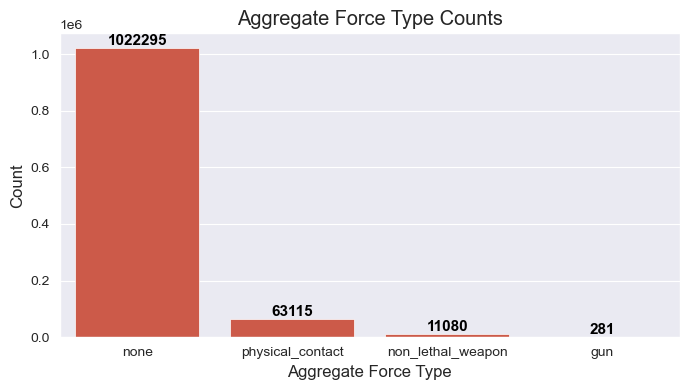

In [429]:
plt.figure(figsize=(7,4))
ax = sns.countplot(x="aggregate_force_type", data=final_df, order=final_df["aggregate_force_type"].value_counts().index)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', fontsize=11, color='black', fontweight='bold'
    )
plt.title("Aggregate Force Type Counts")
plt.xlabel("Aggregate Force Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

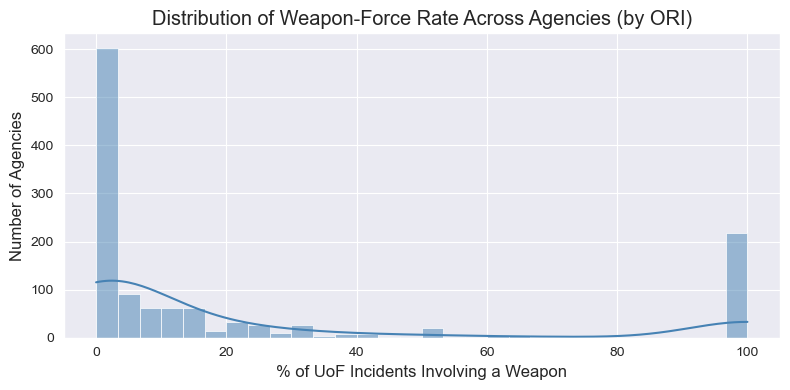

In [430]:
# Combine gun and non_lethal_weapon into a single weapon category
final_df["aggregate_force_type"] = final_df["aggregate_force_type"].replace(
    {"gun": "weapon", "non_lethal_weapon": "weapon"}
)

# Per-agency weapon percentage (only UoF rows)
uof_only = final_df[final_df["is_uof"] == 1]
agency_weapon_pct = (
    uof_only.groupby("ori")["aggregate_force_type"]
    .apply(lambda s: (s == "weapon").mean() * 100)
    .reset_index(name="weapon_pct")
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    agency_weapon_pct["weapon_pct"],
    bins=30,
    kde=True,
    ax=ax,
    color="steelblue",
    edgecolor="white",
)
ax.set_xlabel("% of UoF Incidents Involving a Weapon")
ax.set_ylabel("Number of Agencies")
ax.set_title("Distribution of Weapon-Force Rate Across Agencies (by ORI)")
plt.tight_layout()
plt.show()


In [431]:
agency_weapon_pct["weapon_pct"].describe()

count   1260.0000
mean      23.8572
std       36.8752
min        0.0000
25%        0.0000
50%        4.1250
75%       25.0000
max      100.0000
Name: weapon_pct, dtype: float64

### Excluding NY and Size Filter on ORIs

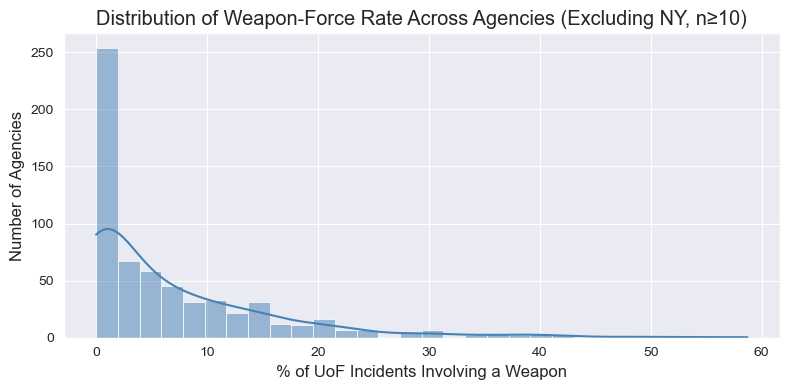

,weapon_pct (%) — excl. NY
Mean,6.9818
Median,3.4705
Variance,86.8849
Std Dev,9.3212
IQR,10.2144
Q1,0.0000
Q3,10.2144
Min,0.0000
Max,58.7097


In [432]:
# Filter out NY agencies (outliers) and replot
MIN_INCIDENTS = 10

uof_no_ny = uof_only[uof_only["state"] != "NY"]
ori_counts = uof_no_ny.groupby("ori").size()
valid_oris = ori_counts[ori_counts >= MIN_INCIDENTS].index

agency_weapon_pct_no_ny = (
    uof_no_ny[uof_no_ny["ori"].isin(valid_oris)]
    .groupby("ori")["aggregate_force_type"]
    .apply(lambda s: (s == "weapon").mean() * 100)
    .reset_index(name="weapon_pct")
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    agency_weapon_pct_no_ny["weapon_pct"],
    bins=30,
    kde=True,
    ax=ax,
    color="steelblue",
    edgecolor="white",
)
ax.set_xlabel("% of UoF Incidents Involving a Weapon")
ax.set_ylabel("Number of Agencies")
ax.set_title(f"Distribution of Weapon-Force Rate Across Agencies (Excluding NY, n≥{MIN_INCIDENTS})")
plt.tight_layout()
plt.show()

# Summary statistics
s2 = agency_weapon_pct_no_ny["weapon_pct"]
q1, q3 = s2.quantile(0.25), s2.quantile(0.75)
stats_no_ny = {
    "Mean":     s2.mean(),
    "Median":   s2.median(),
    "Variance": s2.var(),
    "Std Dev":  s2.std(),
    "IQR":      q3 - q1,
    "Q1":       q1,
    "Q3":       q3,
    "Min":      s2.min(),
    "Max":      s2.max(),
}
pd.Series(stats_no_ny).rename("weapon_pct (%) — excl. NY").to_frame()


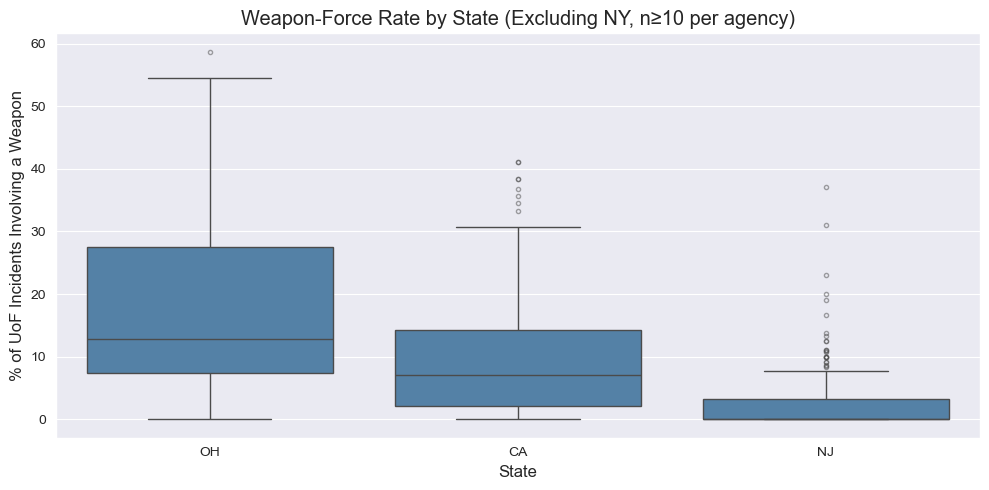

In [433]:
# Weapon % by state — box plot across agencies (excl. NY, n >= MIN_INCIDENTS)
ori_state = uof_no_ny[uof_no_ny["ori"].isin(valid_oris)].groupby("ori")["state"].first()
agency_weapon_pct_no_ny_state = agency_weapon_pct_no_ny.merge(
    ori_state.rename("state"), on="ori"
)

state_order = (
    agency_weapon_pct_no_ny_state.groupby("state")["weapon_pct"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=agency_weapon_pct_no_ny_state,
    x="state",
    y="weapon_pct",
    order=state_order,
    ax=ax,
    color="steelblue",
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
)
ax.set_xlabel("State")
ax.set_ylabel("% of UoF Incidents Involving a Weapon")
ax.set_title(f"Weapon-Force Rate by State (Excluding NY, n≥{MIN_INCIDENTS} per agency)")
plt.tight_layout()
plt.show()


In [434]:
agency_weapon_pct_no_ny.sort_values(by="weapon_pct")

,ori,weapon_pct
311,NJ0021500,0.0000
330,NJ0025900,0.0000
329,NJ0025600,0.0000
328,NJ0025400,0.0000
325,NJ0023900,0.0000
...,...,...
617,OH0780300,45.0000
615,OH0770100,48.8806
608,OH0572200,50.0000
591,OH0310900,54.5455


In [435]:
final_df[lambda x: (x.is_uof == 1) & (x.ori == "OH0570200")].shape

(155, 50)

### Just NY

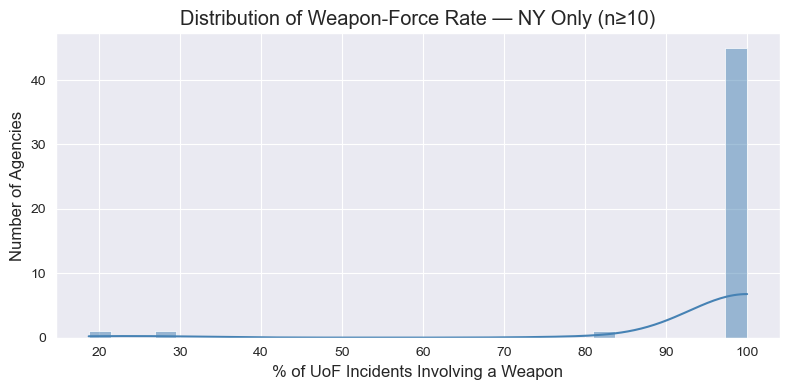

,weapon_pct (%) — NY only
Mean,96.4382
Median,100.0000
Variance,243.4171
Std Dev,15.6018
IQR,0.0000
Q1,100.0000
Q3,100.0000
Min,18.7500
Max,100.0000


In [436]:
# NY only — histogram + KDE and box plot by agency, with size filter
uof_ny = uof_only[uof_only["state"] == "NY"]
ori_counts_ny = uof_ny.groupby("ori").size()
valid_oris_ny = ori_counts_ny[ori_counts_ny >= MIN_INCIDENTS].index

agency_weapon_pct_ny = (
    uof_ny[uof_ny["ori"].isin(valid_oris_ny)]
    .groupby("ori")["aggregate_force_type"]
    .apply(lambda s: (s == "weapon").mean() * 100)
    .reset_index(name="weapon_pct")
)

# --- Histogram + KDE ---
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    agency_weapon_pct_ny["weapon_pct"],
    bins=30,
    kde=True,
    ax=ax,
    color="steelblue",
    edgecolor="white",
)
ax.set_xlabel("% of UoF Incidents Involving a Weapon")
ax.set_ylabel("Number of Agencies")
ax.set_title(f"Distribution of Weapon-Force Rate — NY Only (n≥{MIN_INCIDENTS})")
plt.tight_layout()
plt.show()

# --- Summary statistics ---
s_ny = agency_weapon_pct_ny["weapon_pct"]
q1, q3 = s_ny.quantile(0.25), s_ny.quantile(0.75)
stats_ny = {
    "Mean":     s_ny.mean(),
    "Median":   s_ny.median(),
    "Variance": s_ny.var(),
    "Std Dev":  s_ny.std(),
    "IQR":      q3 - q1,
    "Q1":       q1,
    "Q3":       q3,
    "Min":      s_ny.min(),
    "Max":      s_ny.max(),
}
display(pd.Series(stats_ny).rename("weapon_pct (%) — NY only").to_frame())


# UOF by Race and Agency per Month

In [437]:
# Per (ORI, race, month): UoF count / non-UoF count ratio
final_df["month"] = pd.to_datetime(final_df["date"]).dt.to_period("M")

# Include state (1:1 with ORI)
ori_state_map = final_df.groupby("ori")["state"].first()

ori_race_month = (
    final_df
    .groupby(["ori", "subject_race", "month"])["is_uof"]
    .agg(
        uof_count=lambda x: (x == 1).sum(),
        non_uof_count=lambda x: (x == 0).sum(),
    )
    .reset_index()
    .assign(state=lambda x: x["ori"].map(ori_state_map))
)

# Drop groups with no non-UoF incidents to avoid division by zero
ori_race_month = ori_race_month[ori_race_month["non_uof_count"] > 0].copy()
ori_race_month["ratio"] = ori_race_month["uof_count"] / ori_race_month["non_uof_count"]
ori_race_month["month_dt"] = ori_race_month["month"].dt.to_timestamp()
ori_race_month.head()


,ori,subject_race,month,uof_count,non_uof_count,state,ratio,month_dt
0,CA0010000,asian,2024-01,0,9,CA,0.0000,2024-01-01
1,CA0010000,asian,2024-02,1,7,CA,0.1429,2024-02-01
2,CA0010000,asian,2024-03,1,13,CA,0.0769,2024-03-01
3,CA0010000,asian,2024-04,0,15,CA,0.0000,2024-04-01
4,CA0010000,asian,2024-05,0,14,CA,0.0000,2024-05-01


In [438]:
# Time series: mean ratio across ORIs per (race, month) — excl. NY, size filtered
# Size filter: keep (ORI, race) pairs with >= MIN_INCIDENTS total UoF across all months
valid_ori_race = (
    ori_race_month[ori_race_month["state"] != "NY"]
    .groupby(["ori", "subject_race"])["uof_count"]
    .sum()
    .loc[lambda s: s >= 0]
    .index
)

orm_filtered = ori_race_month[
    (ori_race_month["state"] != "NY")
    & (pd.MultiIndex.from_arrays([ori_race_month["ori"], ori_race_month["subject_race"]]).isin(valid_ori_race))
]

mean_ratio = (
    orm_filtered
    .groupby(["subject_race", "month_dt"])["ratio"]
    .mean()
    .reset_index()
    .rename(columns={"subject_race": "Race", "month_dt": "Month", "ratio": "Mean UoF / Non-UoF Ratio"})
)

fig = px.line(
    mean_ratio,
    x="Month",
    y="Mean UoF / Non-UoF Ratio",
    color="Race",
    markers=True,
    title=f"Average UoF Rate Ratio by Race Over Time (Excl. NY, n≥{0})",
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Mean UoF / Non-UoF Ratio (across ORIs)",
    legend_title="Race",
    hovermode="x unified",
)
fig.show()


In [439]:
final_df["subject_race"].value_counts()

subject_race
white               381413
hispanic            341626
black               311726
asian                34547
unknown              19914
native american       5030
pacific islander      2515
Name: count, dtype: int64

/var/folders/8r/qgk4_l1j20gfq28wvs_pxh2r0000gn/T/ipykernel_88096/1097517497.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


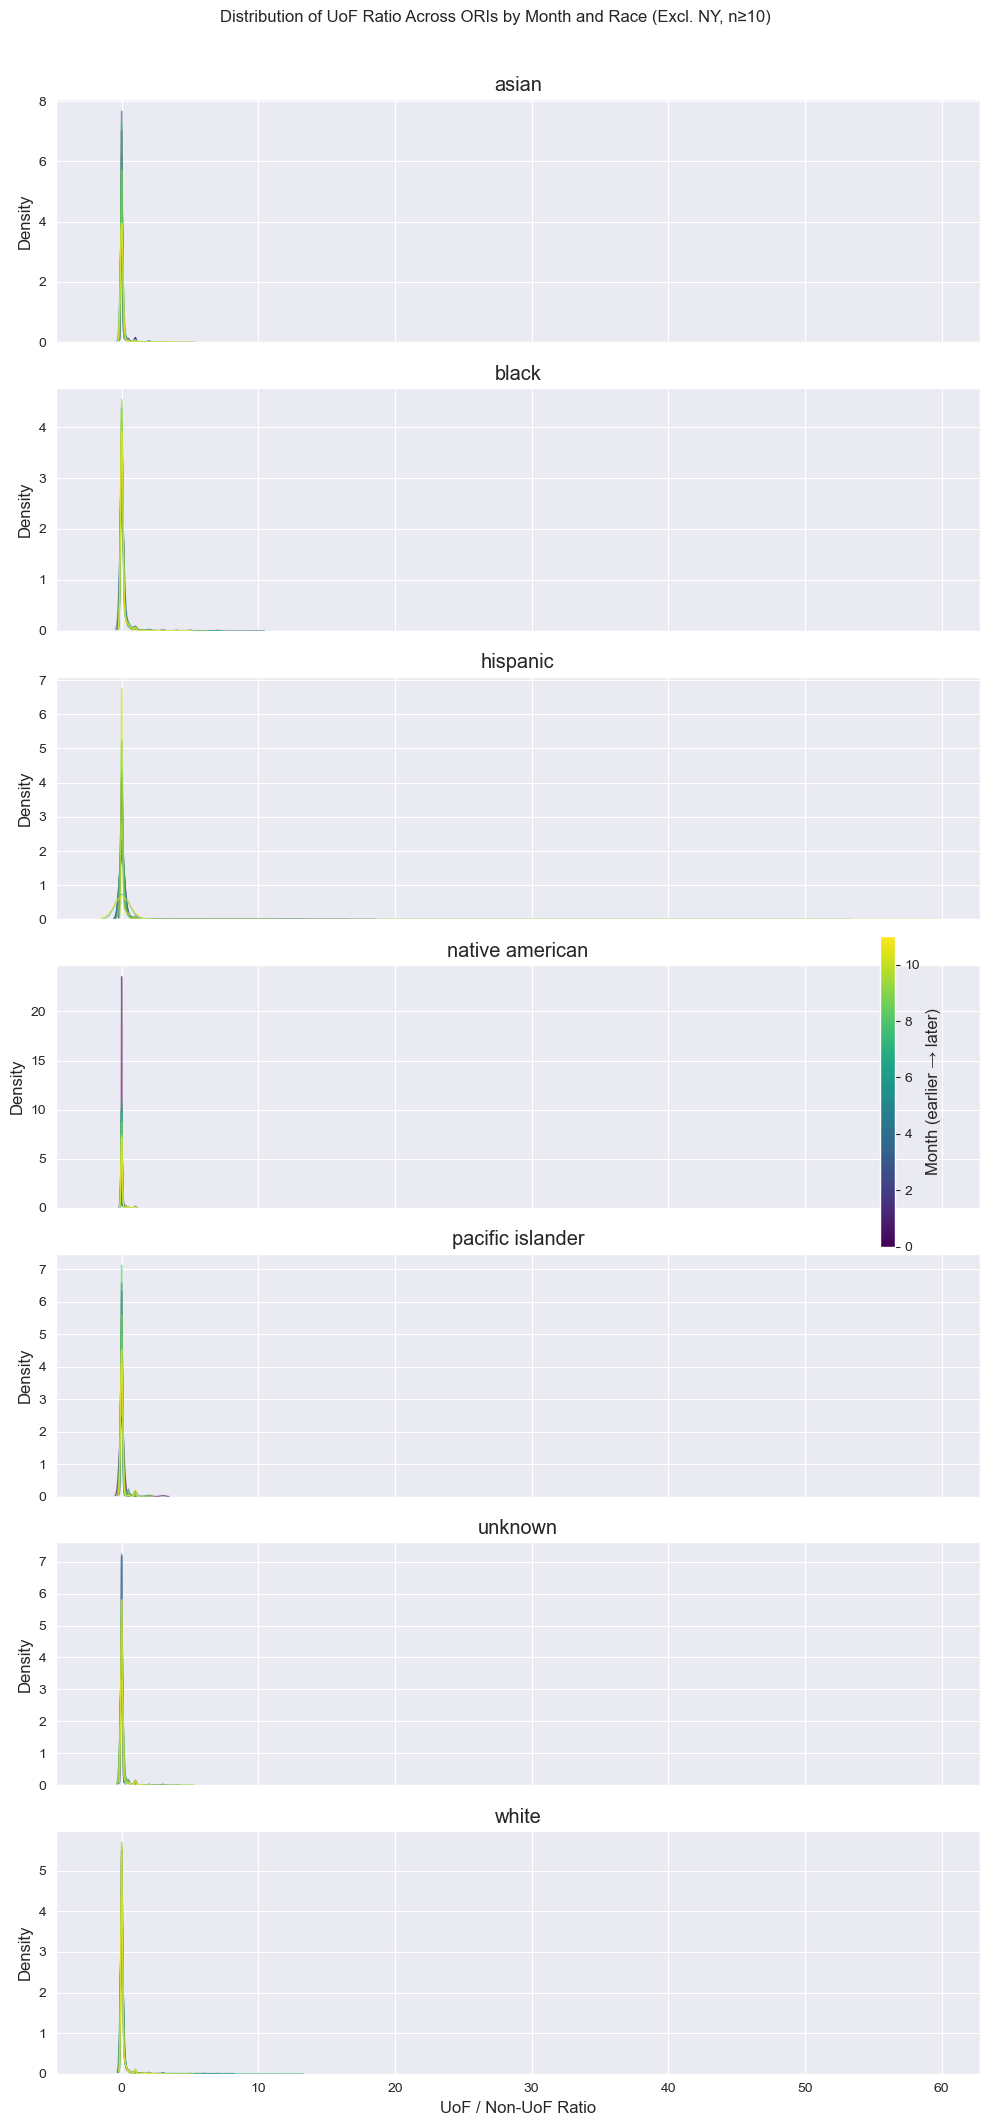

In [440]:
# KDE of ratio across ORIs per month, faceted by race — excl. NY, size filtered
races = sorted(orm_filtered["subject_race"].dropna().unique())
months = sorted(orm_filtered["month"].unique())
cmap = plt.cm.viridis
month_colors = {m: cmap(i / max(len(months) - 1, 1)) for i, m in enumerate(months)}

fig, axes = plt.subplots(len(races), 1, figsize=(10, 3 * len(races)), sharex=True)
if len(races) == 1:
    axes = [axes]

for ax, race in zip(axes, races):
    subset = orm_filtered[orm_filtered["subject_race"] == race]
    for month in months:
        data = subset[subset["month"] == month]["ratio"].dropna()
        if len(data) >= 2:
            sns.kdeplot(data, ax=ax, color=month_colors[month], alpha=0.6, linewidth=1)
    ax.set_title(f"{race}")
    ax.set_ylabel("Density")

axes[-1].set_xlabel("UoF / Non-UoF Ratio")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, len(months) - 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, fraction=0.02)
cbar.set_label("Month (earlier → later)")

fig.suptitle(f"Distribution of UoF Ratio Across ORIs by Month and Race (Excl. NY, n≥{MIN_INCIDENTS})", y=1.01)
plt.tight_layout()
plt.show()
